## Baseline-Modell

# Erstellt je User einen Case/Trace mit den dazugehörigen Events (Zustandsverläufen).
# Insgesamt 5 Zustände möglich.
Ob die Patienten Tinnitus hatten oder nicht, wird beachtet.

In [28]:
# Bibliotheken und Co laden
import pandas as pd
import numpy as np
from jinja2.nodes import Output
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.algo.filtering.log.variants import variants_filter
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import seaborn as sns

In [29]:
# CSV laden
df = pd.read_csv('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-02 TYT_answers2.csv', sep=";")

# Überblick verschaffen

In [30]:
df.head()

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,notification_fixed,created_at,updated_at,date_of_birth2,age,famhistory,gender,handedness,onset_date2,onset_duration
0,2959,1.0,6.0,4.0,5.0,3.0,8.0,3.0,1.0,-688.462,...,0,22.04.14 13:58,22.04.14 13:58,14.02.79,35,0.0,0.0,0.0,14.02.10,4
1,2998,1.0,5.0,5.0,5.0,5.0,7.0,8.0,1.0,-109.410,...,0,27.04.14 08:10,27.04.14 08:10,14.02.79,35,0.0,0.0,0.0,14.02.10,4
2,3002,0.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,-120.225,...,0,28.04.14 15:45,28.04.14 15:45,14.02.79,35,0.0,0.0,0.0,14.02.10,4
3,3003,0.0,8.0,7.0,3.0,6.0,5.0,6.0,1.0,-394.602,...,0,28.04.14 15:45,28.04.14 15:45,14.02.79,35,0.0,0.0,0.0,14.02.10,4
4,3054,0.0,NaN,1.0,NaN,NaN,NaN,NaN,0.0,-187.568,...,0,22.05.14 12:58,22.05.14 12:58,14.02.79,35,0.0,0.0,0.0,14.02.10,4


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112190 entries, 0 to 112189
Data columns (total 29 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  112190 non-null  int64  
 1   q1                  110565 non-null  float64
 2   q2                  110264 non-null  float64
 3   q3                  104169 non-null  float64
 4   q4                  109385 non-null  float64
 5   q5                  107775 non-null  float64
 6   q6                  103110 non-null  float64
 7   q7                  106857 non-null  float64
 8   q8                  108792 non-null  float64
 9   soundlevel          110045 non-null  float64
 10  sound_rounded       112190 non-null  int64  
 11  sound_env           110045 non-null  float64
 12  sound_env2          110045 non-null  str    
 13  user_id             112190 non-null  int64  
 14  user_os             112190 non-null  str    
 15  user_agent          112190 non-null  str    


In [32]:
df.describe(include="all")

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,notification_fixed,created_at,updated_at,date_of_birth2,age,famhistory,gender,handedness,onset_date2,onset_duration
count,112190.000000,110565.000000,110264.000000,104169.000000,109385.000000,107775.000000,103110.000000,106857.000000,108792.000000,110045.000000,...,112190.000000,112190,112190,107193,110582,109714.000000,109641.000000,109756.000000,106169,110581
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,95272,95272,2880,84,NaN,NaN,NaN,1999,63
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,08.09.20 12:28,08.09.20 12:28,24.02.61,57,NaN,NaN,NaN,01.07.87,0
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,132,132,6815,7121,NaN,NaN,NaN,6817,20311
mean,60649.225689,0.800308,4.817883,3.754121,5.719943,2.546398,2.761643,5.929139,0.326982,701.249939,...,0.224610,NaN,NaN,NaN,NaN,0.206655,0.249368,0.370649,NaN,NaN
std,33379.682422,0.399771,3.137693,2.901579,2.199984,2.332471,2.445803,3.259860,0.469113,2517.894896,...,0.417327,NaN,NaN,NaN,NaN,0.404908,0.432649,0.686600,NaN,NaN
min,2959.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-998.378000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
25%,31524.250000,1.000000,2.000000,1.000000,5.000000,0.000000,1.000000,3.000000,0.000000,-355.795000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
50%,61250.500000,1.000000,4.000000,3.000000,5.000000,3.000000,2.000000,6.000000,0.000000,0.000000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN
75%,89622.750000,1.000000,7.000000,6.000000,8.000000,4.000000,4.000000,9.000000,1.000000,436.000000,...,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN


In [33]:
# Einzigartige Fälle
print("Anzahl Cases:", df["id"].nunique())

Anzahl Cases: 112184


In [34]:
# Einzigartige User
print("Anzahl User:", df["user_id"].nunique())

Anzahl User: 3339


In [35]:
# Einträge je User
print(f"Durchschnittliche Einträge pro User: {112184/3339:.2f}")

Durchschnittliche Einträge pro User: 33.60


In [36]:
# Fehlende Werte finden
df.isna().sum()

id                        0
q1                     1625
q2                     1926
q3                     8021
q4                     2805
q5                     4415
q6                     9080
q7                     5333
q8                     3398
soundlevel             2145
sound_rounded             0
sound_env              2145
sound_env2             2145
user_id                   0
user_os                   0
user_agent                0
save_date                 0
autosaved                 0
notification_date     92969
notification_fixed        0
created_at                0
updated_at                0
date_of_birth2         4997
age                    1608
famhistory             2476
gender                 2549
handedness             2434
onset_date2            6021
onset_duration         1609
dtype: int64

In [37]:
# IDs finden, bei denen age fehlt
users_with_missing_age = df[df["age"].isna()]["user_id"].unique()

print(f"Anzahl User mit fehlendem Age: {len(users_with_missing_age)}")
print("User IDs:", users_with_missing_age)

Anzahl User mit fehlendem Age: 43
User IDs: [  103   794   905  1708  1743  1747  1807  1828  1840  1884  1904  1907
  1911  1917  1918  1923  1932  1941  1954  1975  1984  2006  2017  2020
  2031  2050  2070  2117  2129  2238  2239  2259  2361  2414  2426  2463
  2471  2475  4941 28481 31298 34230 37214]


In [38]:
# IDs finden, bei denen gender fehlt
users_with_missing_gender = df[df["gender"].isna()]["user_id"].unique()

print(f"Anzahl User mit fehlendem Gender: {len(users_with_missing_gender)}")
print("User IDs:", users_with_missing_gender)

Anzahl User mit fehlendem Gender: 88
User IDs: [  103   410   536   554   569   570   573   580   582   583   584   585
   586   589   590   591   592   593   594   597   600   606   610   611
   613   614   615   619   620   622   623   625   771   794   905   978
  1161  1705  1708  1743  1747  1790  1807  1828  1838  1840  1884  1904
  1907  1911  1917  1918  1923  1932  1941  1945  1954  1975  1984  2006
  2017  2020  2031  2050  2070  2110  2117  2129  2238  2239  2259  2328
  2361  2364  2414  2426  2463  2471  2475  2928  3134  3591  3717  4941
 28481 31298 34230 37214]


In [39]:
# IDs finden, bei denen onset_duration fehlt
users_with_missing_onset_duration = df[df["onset_duration"].isna()]["user_id"].unique()

print(f"Anzahl User mit fehlendem onset_duration: {len(users_with_missing_onset_duration)}")
print("User IDs:", users_with_missing_onset_duration)

Anzahl User mit fehlendem onset_duration: 44
User IDs: [  103   325   794   905  1708  1743  1747  1807  1828  1840  1884  1904
  1907  1911  1917  1918  1923  1932  1941  1954  1975  1984  2006  2017
  2020  2031  2050  2070  2117  2129  2238  2239  2259  2361  2414  2426
  2463  2471  2475  4941 28481 31298 34230 37214]


# Aufräumen

In [40]:
# Schauen, ob zwei Spalten redundante Inhalte haben
# bei True sind die Inhalte 1:1 gleich
df["created_at"].equals(df["updated_at"])

True

In [41]:
# Schauen, ob die Infos in der Spalte überhaupt relevant sind
df["user_agent"]

0         TrackYourTinnitus/1.1.1 (iPhone; iOS 7.1; Scal...
1         TrackYourTinnitus/1.1.1 (iPhone; iOS 7.1.1; Sc...
2         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
3         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
4         TrackYourTinnitus/1.1.2 (iPhone; iOS 7.1.1; Sc...
                                ...                        
112185    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 16.3.1;...
112186    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 16.7.5;...
112187    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.4.1;...
112188    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.5.1;...
112189    TrackYourTinnitus/1.2.1.1 (iPhone; iOS 17.5.1;...
Name: user_agent, Length: 112190, dtype: str

In [42]:
# Schauen, ob die Infos in der Spalte überhaupt relevant sind
df["autosaved"]

0         1
1         0
2         1
3         0
4         1
         ..
112185    0
112186    0
112187    0
112188    0
112189    0
Name: autosaved, Length: 112190, dtype: int64

In [43]:
# Spalten "user_agent", "updated_at" und "autosaved" entfernen.
# zudem "notification_fixed" und "notification_date" entfernen, da Miriam sie für unwichtig erklärt hat
df = df.drop(columns=["user_agent", "updated_at", "autosaved", "notification_fixed", "notification_date"])

In [44]:
# Wir werden Soundlevel selbst nochmal in auswertbare Werte zws den OS umwandeln.
# Daher könnten wir eigentlich "sound_env", "sound_env2" und "sound_rounded" entfernen.
df = df.drop(columns=["sound_env", "sound_env2", "sound_rounded"])

In [45]:
df.columns

Index(['id', 'q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7', 'q8', 'soundlevel',
       'user_id', 'user_os', 'save_date', 'created_at', 'date_of_birth2',
       'age', 'famhistory', 'gender', 'handedness', 'onset_date2',
       'onset_duration'],
      dtype='str')

In [46]:
# Zeitspalten konvertieren
time_cols = ["save_date", "created_at"]
for col in time_cols:
    df[col] = pd.to_datetime(df[col], format="%d.%m.%y %H:%M", errors="coerce")

# Andere Zeitspalten konvertieren
date_cols = ["date_of_birth2", "onset_date2"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d.%m.%y", errors="coerce")

# Geschlecht & Alter (Missing Values Check & Vorbereitung)
# Erstellung einer Flag für fehlende demografische Daten, um später deren Einfluss prüfen zu können.
df["missing_demographics"] = df["gender"].isna() | df["age"].isna()

# Soundlevel nach OS trennen
# Erstellung zwei separater Spalten für die Sound-Umgebung (Skalen zsw. iOS und Android nicht direkt vergleichbar).
df["sound_ios"] = df.loc[df["user_os"] == "iOS", "soundlevel"]
df["sound_android"] = df.loc[df["user_os"] == "android", "soundlevel"]

# Normalisierung (Z-Transformation) pro OS, um eine einzige Spalte zu haben.
df["sound_norm"] = df.groupby("user_os")["soundlevel"].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
)

# Zeitdifferenz zws. Einträgen je User berechnen (created_at)
# Zuerst nach User und Zeit sortieren, dann Differenz zum vorherigen Event berechnen.
df = df.sort_values(by=["user_id", "created_at"])
df["time_to_prev_event"] = df.groupby("user_id")["created_at"].diff().dt.days

In [47]:
print(df.groupby("user_os")["soundlevel"].describe())

           count         mean          std      min        25%       50%  \
user_os                                                                    
Android  60377.0  1561.787667  3144.501888    0.000    0.00000  330.0000   
iOS      49668.0  -344.829759   179.678665 -998.378 -484.00975 -381.4065   

            75%        max  
user_os                     
Android  1577.0  32124.000  
iOS      -120.0    -10.147  


In [48]:
print(df["time_to_prev_event"].mean())

2.8359684339142497


In [49]:
# Schauen, dass Werte von Q1-Q8 im erlaubten Bereich sind
# q1 und q8 (0 oder 1)
invalid_q1_q8 = df[
    (df["q1"] < 0) | (df["q1"] > 1) |
    (df["q8"] < 0) | (df["q8"] > 1)
]
print("q1/q8 Fehler:", len(invalid_q1_q8))

# q2 bis q7 (0–10)
invalid_q2_q7 = df[
    (df[["q2","q3","q4","q5","q6","q7"]] < 0).any(axis=1) |
    (df[["q2","q3","q4","q5","q6","q7"]] > 10).any(axis=1)
]
print("q2–q7 Fehler:", len(invalid_q2_q7))

q1/q8 Fehler: 0
q2–q7 Fehler: 0


In [50]:
# Schauen, dass "age" nicht <0 oder >110 ist
df["age"] = pd.to_numeric(df["age"], errors="coerce")
invalid_age = df[(df["age"] < 0) | (df["age"] > 110)]

print(invalid_age[["id", "user_id", "age"]])

          id  user_id    age
10948  12172      835  113.0


In [51]:
# Sicherstellen, dass "age" numerisch ist
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# Alter und Onset_duration auf NaN setzen
df.loc[(df["user_id"] == 835) & ((df["age"] < 0) | (df["age"] > 110)), "age"] = pd.NA
df.loc[(df["user_id"] == 835), "onset_duration"] = pd.NA

# Kontrolle
df[df["user_id"] == 835]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_ios,sound_android,sound_norm,time_to_prev_event
10948,12172,1.0,9.0,10.0,0.0,0.0,9.0,5.0,1.0,909.0,...,0.0,0.0,2.0,2002-03-12,NaN,False,NaN,NaN,-0.207597,NaN


In [52]:
df.isna().sum()

id                           0
q1                        1625
q2                        1926
q3                        8021
q4                        2805
q5                        4415
q6                        9080
q7                        5333
q8                        3398
soundlevel                2145
user_id                      0
user_os                      0
save_date                  612
created_at                   0
date_of_birth2            4997
age                       5611
famhistory                2476
gender                    2549
handedness                2434
onset_date2               6021
onset_duration            1610
missing_demographics         0
sound_ios                62522
sound_android           112190
sound_norm                2145
time_to_prev_event        3339
dtype: int64

## Missing Data Strategie fahren

In [53]:
# für uns wäre es meiner Meinung nach wichtig, Missing Data bei q1-q8 zu korrigieren.
# am wichtigsten ist eigentlich q1. Wenn's nicht ausgefüllt ist, dann ... machen.

'''
# einfach ignorieren und somit nichts machen
'''

'''
# Löschen von Zeilen mit fehlenden q1 Werten
df = df.dropna(subset=["q1"])
'''

'''
# Fehlende q1 Werte mit -1 ersetzen. Später evtl. als eigene Gruppe analysierbar.
df["q1"] = df["q1"].fillna(-1).astype(int)
'''

'''
# Fehlende q1 Werte mit dem Mittelwert ersetzen
# Mittelwert berechnen und aufrunden
mean_val = df["q1"].mean()
rounded_val = int(np.ceil(mean_val)) # aus 0.80 wird 1
# Fehlende Werte ersetzen
df["q1"] = df["q1"].fillna(rounded_val)
print(f"Eingesetzter Mittelwert: {rounded_val}")
'''

'''
# Fehlende q1 Werte mit dem Median ersetzen
# Median berechnen
median_q1 = df["q1"].median()
# Fehlende Werte ersetzen
df["q1"] = df["q1"].fillna(median_q1)
print(f"Eingesetzter Median: {median_q1}")
'''

'''
# Fehlende q1 Werte mit kNN=5 ersetzen
# 1. Spalten auswählen, die für die Ähnlichkeit relevant sind
impute_cols = ["q1", "sound_env", "age", "gender"]

# Falls gender/sound_env Text sind, müssen sie in Zahlen umgewandelt werden (Faktorisiert)
df_impute = df[impute_cols].copy()

# Beispiel für kategorische Daten (falls nötig):
for col in df_impute.select_dtypes(include=['object']).columns:
    df_impute[col] = pd.factorize(df_impute[col])[0]

# 2. KNN Imputer konfigurieren (=5)
imputer = KNNImputer(n_neighbors=5)

# 3. Fehlende Werte schätzen
df_filled = imputer.fit_transform(df_impute)

# 4. Den Wert zurück in den originalen DataFrame schreiben
df["q1"] = df_filled[:, 0] # q1 ist die erste Spalte (Index 0)

# 5. Ergebnis auf 0 oder 1 runden
df["q1"] = df["q1"].round().astype(int)
'''

'\n# Fehlende q1 Werte mit kNN=5 ersetzen\n# 1. Spalten auswählen, die für die Ähnlichkeit relevant sind\nimpute_cols = ["q1", "sound_env", "age", "gender"]\n\n# Falls gender/sound_env Text sind, müssen sie in Zahlen umgewandelt werden (Faktorisiert)\ndf_impute = df[impute_cols].copy()\n\n# Beispiel für kategorische Daten (falls nötig):\nfor col in df_impute.select_dtypes(include=[\'object\']).columns:\n    df_impute[col] = pd.factorize(df_impute[col])[0]\n\n# 2. KNN Imputer konfigurieren (=5)\nimputer = KNNImputer(n_neighbors=5)\n\n# 3. Fehlende Werte schätzen\ndf_filled = imputer.fit_transform(df_impute)\n\n# 4. Den Wert zurück in den originalen DataFrame schreiben\ndf["q1"] = df_filled[:, 0] # q1 ist die erste Spalte (Index 0)\n\n# 5. Ergebnis auf 0 oder 1 runden\ndf["q1"] = df["q1"].round().astype(int)\n'

In [54]:
# Kontrolle ob q1 noch fehlende Werte hat
df.isna().sum()

id                           0
q1                        1625
q2                        1926
q3                        8021
q4                        2805
q5                        4415
q6                        9080
q7                        5333
q8                        3398
soundlevel                2145
user_id                      0
user_os                      0
save_date                  612
created_at                   0
date_of_birth2            4997
age                       5611
famhistory                2476
gender                    2549
handedness                2434
onset_date2               6021
onset_duration            1610
missing_demographics         0
sound_ios                62522
sound_android           112190
sound_norm                2145
time_to_prev_event        3339
dtype: int64

## User mit nur einem Eintrag entfernen

In [55]:
print(f"Anzahl einzigartiger Nutzer vor dem Entfernen: {df['user_id'].nunique()}")
# Behalte nur die user_id's, die mehr als einen Eintrag haben
df = df.groupby("user_id").filter(lambda x: len(x) > 1)

# Optional: Index zurücksetzen nach dem Löschen
#df = df.reset_index(drop=True)

# Kurze Kontrolle
print(f"Verbleibende Einträge: {len(df)}")
print(f"Anzahl einzigartiger Nutzer nach dem Entfernen: {df['user_id'].nunique()}")
print(f"Entfernte Nutzer: {3339-df['user_id'].nunique()}")

# Entfernte Nutzer in %
print(f"Entfernte Nutzer: {(1018/3339)*100:.2f}%")

Anzahl einzigartiger Nutzer vor dem Entfernen: 3339
Verbleibende Einträge: 111172
Anzahl einzigartiger Nutzer nach dem Entfernen: 2321
Entfernte Nutzer: 1018
Entfernte Nutzer: 30.49%


# Daten aufbereiten

In [56]:
df[df["created_at"].isna()]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_ios,sound_android,sound_norm,time_to_prev_event


In [57]:
df[df["save_date"].isna()]

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_ios,sound_android,sound_norm,time_to_prev_event
2633,3189,0.0,8.0,4.0,4.0,5.0,2.0,9.0,1.0,NaN,...,0.0,0.0,1.0,NaT,#WERT!,False,NaN,NaN,NaN,NaN
2634,3190,1.0,7.0,5.0,NaN,NaN,NaN,NaN,0.0,-425.513,...,0.0,0.0,1.0,NaT,#WERT!,False,-425.513,NaN,-0.449042,0.0
2635,3191,1.0,6.0,4.0,4.0,NaN,NaN,NaN,0.0,NaN,...,0.0,0.0,1.0,NaT,#WERT!,False,NaN,NaN,NaN,0.0
2636,3192,1.0,5.0,2.0,4.0,5.0,2.0,7.0,1.0,-350.426,...,0.0,0.0,1.0,NaT,#WERT!,False,-350.426,NaN,-0.031146,0.0
2637,3193,1.0,6.0,5.0,4.0,NaN,NaN,NaN,0.0,-539.439,...,1.0,0.0,0.0,1995-03-07,#WERT!,False,-539.439,NaN,-1.083096,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110295,110864,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,-522.364,NaN,-0.988065,0.0
110296,110865,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,-522.364,NaN,-0.988065,0.0
110297,110866,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,-522.364,NaN,-0.988065,0.0
110298,110867,1.0,6.0,5.0,0.0,6.0,2.0,1.0,0.0,-522.364,...,0.0,1.0,2.0,2009-01-06,#WERT!,False,-522.364,NaN,-0.988065,0.0


In [58]:
# Spalte "save_date" entfernen. Wir werden "created_at" als Zeitstempel nehmen
df = df.drop(columns=["save_date"])

In [59]:
# Änderungen kontrollieren
df.head()

,id,q1,q2,q3,q4,q5,q6,q7,q8,soundlevel,...,famhistory,gender,handedness,onset_date2,onset_duration,missing_demographics,sound_ios,sound_android,sound_norm,time_to_prev_event
0,2959,1.0,6.0,4.0,5.0,3.0,8.0,3.0,1.0,-688.462,...,0.0,0.0,0.0,2010-02-14,4,False,-688.462,NaN,-1.912482,NaN
1,2998,1.0,5.0,5.0,5.0,5.0,7.0,8.0,1.0,-109.410,...,0.0,0.0,0.0,2010-02-14,4,False,-109.410,NaN,1.310227,4.0
2,3002,0.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,-120.225,...,0.0,0.0,0.0,2010-02-14,4,False,-120.225,NaN,1.250036,1.0
3,3003,0.0,8.0,7.0,3.0,6.0,5.0,6.0,1.0,-394.602,...,0.0,0.0,0.0,2010-02-14,4,False,-394.602,NaN,-0.277007,0.0
4,3054,0.0,NaN,1.0,NaN,NaN,NaN,NaN,0.0,-187.568,...,0.0,0.0,0.0,2010-02-14,4,False,-187.568,NaN,0.875239,23.0


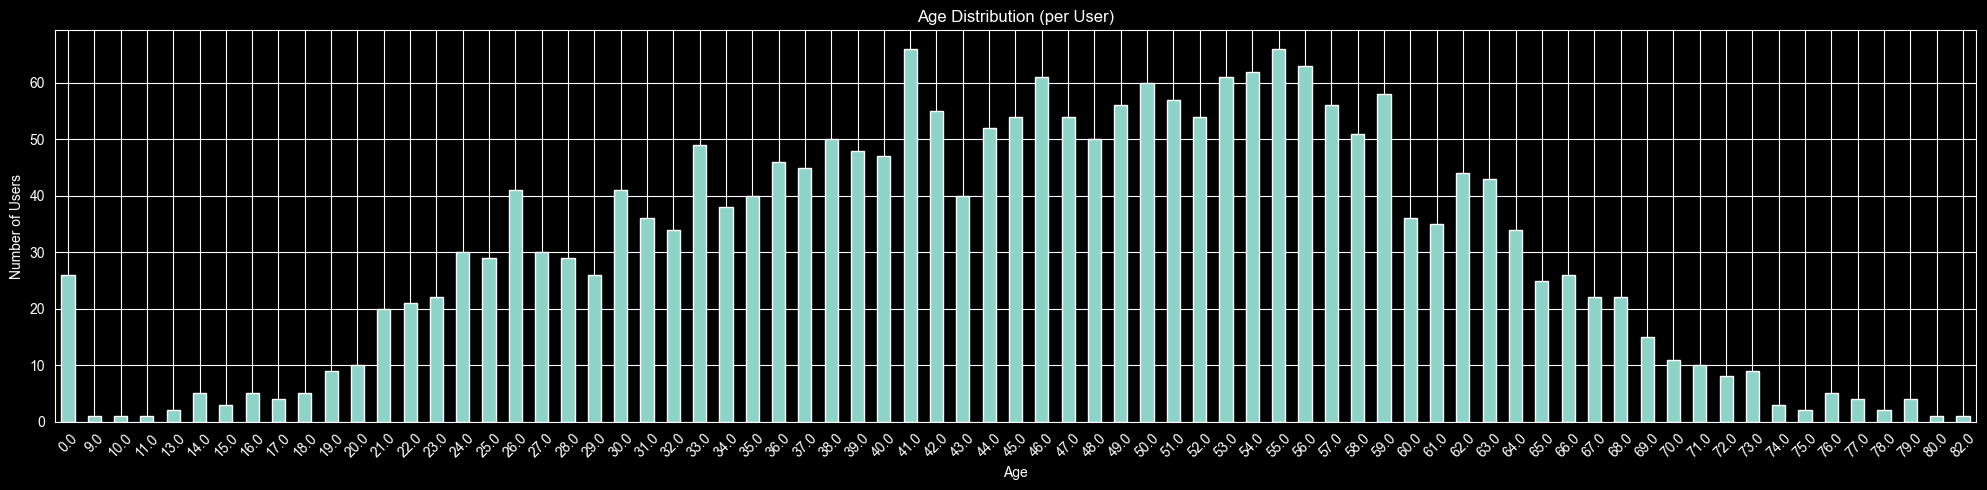

In [60]:
# Verteilung der User nach Alter ausgeben

# pro User genau ein Eintrag (z. B. erster Eintrag)
df_user = df.drop_duplicates(subset="user_id")

plt.figure(figsize=(20,5))

df_user["age"].value_counts().sort_index().plot(kind="bar")

plt.title("Age Distribution (per User)")
plt.xlabel("Age")
plt.ylabel("Number of Users")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Feature Engineering und statistische Analyse

## Vorbereitung

In [61]:
# Score berechnen (ohne q1 und q8. Zudem mit Mittelwert von q2 und q3 und invertierter q4 Werte)
# Neue Spalte für den Mittelwert erstellen.
df["mean_q2_q3"] = df[["q2", "q3"]].mean(axis=1)

# q4 Werte invertieren
df['q4_inv'] = 10 - df['q4']

# Score erstellen
df["score"] = df[["mean_q2_q3","q4_inv","q5","q6","q7"]].sum(axis=1)

# Kategorien definieren (durch 5 geteilt)
def categorize(score):
    if score <= 10:
        return "level 1"
    elif score <= 20:
        return "level 2"
    elif score <= 30:
        return "level 3"
    elif score <= 40:
        return "level 4"
    else:
        return "level 5"

df["score2"] = df["score"].apply(categorize)

df["state_with_tinnitus"] = (df["score2"] + "_" + df["q1"].astype(str))

df["concept:name"] = df["state_with_tinnitus"]


'''
# Kategorien definieren (in 5 Quantile geteilt)
df["concept:name"] = pd.qcut(
    df["score"],
    q=5,
    labels=["level 1", "level 2", "level 3", "level 4", "level 5"]
)
'''

'\n# Kategorien definieren (in 5 Quantile geteilt)\ndf["concept:name"] = pd.qcut(\n    df["score"],\n    q=5,\n    labels=["level 1", "level 2", "level 3", "level 4", "level 5"]\n)\n'

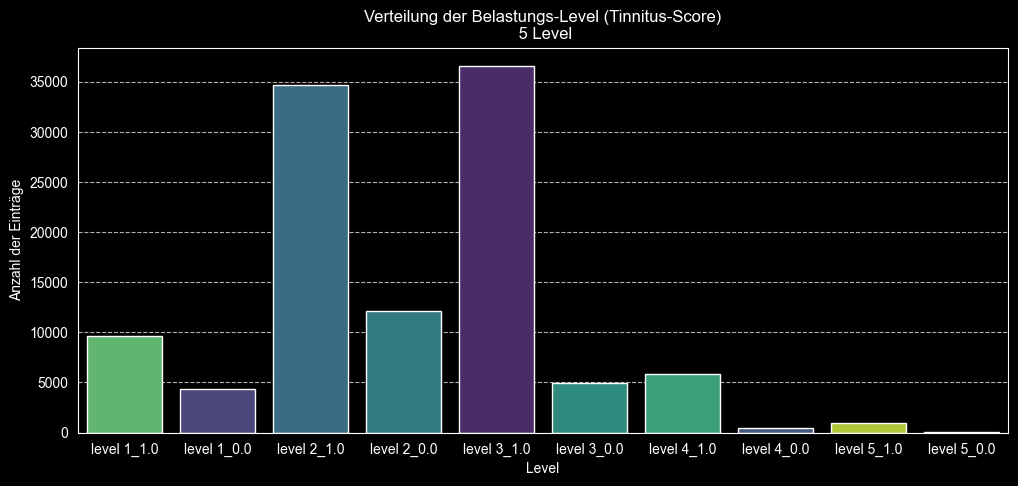

In [62]:
# Verteilung der Level visualisieren
plt.figure(figsize=(12, 5))

# Reihenfolge der Balken bestimmen
level_order = ["level 1_1.0", "level 1_0.0", "level 2_1.0","level 2_0.0","level 3_1.0","level 3_0.0","level 4_1.0","level 4_0.0","level 5_1.0","level 5_0.0"]

sns.countplot(data=df, x="concept:name", order=level_order, palette="viridis", hue="concept:name", legend=False)

plt.title("Verteilung der Belastungs-Level (Tinnitus-Score)\n 5 Level")
plt.xlabel("Level")
plt.ylabel("Anzahl der Einträge")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [63]:
# 1. Die Zählung der Einträge (Events) pro Zustand durchführen
distribution = df["concept:name"].value_counts().reset_index()
distribution.columns = ["Zustand (Level_Tinnitus)", "Anzahl_Einträge"]

# 2. Die Tabelle nach deiner vordefinierten Reihenfolge sortieren
level_order = ["level 1_1.0","level 1_0.0","level 2_1.0", "level 2_0.0","level 3_1.0", "level 3_0.0", "level 4_1.0", "level 4_0.0","level 5_1.0", "level 5_0.0"]

# Wir setzen die Spalte als "Categorical", um die Sortierung zu erzwingen
distribution["Zustand (Level_Tinnitus)"] = pd.Categorical(distribution["Zustand (Level_Tinnitus)"],categories=level_order,ordered=True)

distribution = distribution.sort_values("Zustand (Level_Tinnitus)")

# 3. Tabelle ausgeben
#print(distribution.to_string(index=False))
total = distribution["Anzahl_Einträge"].sum()
distribution["Anteil_in_Prozent"] = (distribution["Anzahl_Einträge"] / total * 100).round(2)
print("Mit prozentualem Anteil:")
print(distribution.to_string(index=False))

Mit prozentualem Anteil:
Zustand (Level_Tinnitus)  Anzahl_Einträge  Anteil_in_Prozent
             level 1_1.0             9631               8.79
             level 1_0.0             4308               3.93
             level 2_1.0            34639              31.62
             level 2_0.0            12121              11.06
             level 3_1.0            36576              33.39
             level 3_0.0             4975               4.54
             level 4_1.0             5863               5.35
             level 4_0.0              458               0.42
             level 5_1.0              929               0.85
             level 5_0.0               57               0.05


In [64]:
# Berechnung der prozentualen Verteilung der Level
dist = df["concept:name"].value_counts(normalize=True).reindex(level_order) * 100

print("--- Prozentuale Verteilung der Level ---")
print(dist.map("{:.1f}%".format))

--- Prozentuale Verteilung der Level ---
concept:name
level 1_1.0     8.8%
level 1_0.0     3.9%
level 2_1.0    31.6%
level 2_0.0    11.1%
level 3_1.0    33.4%
level 3_0.0     4.5%
level 4_1.0     5.4%
level 4_0.0     0.4%
level 5_1.0     0.8%
level 5_0.0     0.1%
Name: proportion, dtype: str


In [65]:
# Fix für #ZAHL! bei onset_duration
# Alle nicht-numerischen Werte in onset_duration zu NaN machen
df["onset_duration"] = pd.to_numeric(df["onset_duration"], errors="coerce")

In [66]:
# Sound - Veränderungen berechnen (Delta)
df = df.sort_values(by=["user_id", "created_at"])
df['delta_sound'] = df.groupby('user_id')['sound_norm'].diff()
df['delta_score'] = df.groupby('user_id')['score'].diff()

# Dynamische Schwelle zur Bias-Korrektur (OS-spezifisch)
# Berechnung des 95%-Quantil für jedes OS, um unterschiedliche Hardware-Varianz auszugleichen
os_thresholds = df.groupby('user_os')['delta_sound'].transform(lambda x: x.quantile(0.95)) # wenn delta_sound eine Veränderung > 5% hat = Verschlechterung

# Flag setzen: War das vorherige Event eine Sound-Verschlechterung?
df['after_noise_burst'] = df.groupby('user_id')['delta_sound'].shift(1) > os_thresholds
df['after_noise_burst'] = df['after_noise_burst'].fillna(False)

# Optional: Validierung/Dokumentation der Verteilung
'''print("Verwendete Schwellenwerte pro OS:")
print(df.groupby('user_os')['delta_sound'].quantile(0.95))'''

'print("Verwendete Schwellenwerte pro OS:")\nprint(df.groupby(\'user_os\')[\'delta_sound\'].quantile(0.95))'

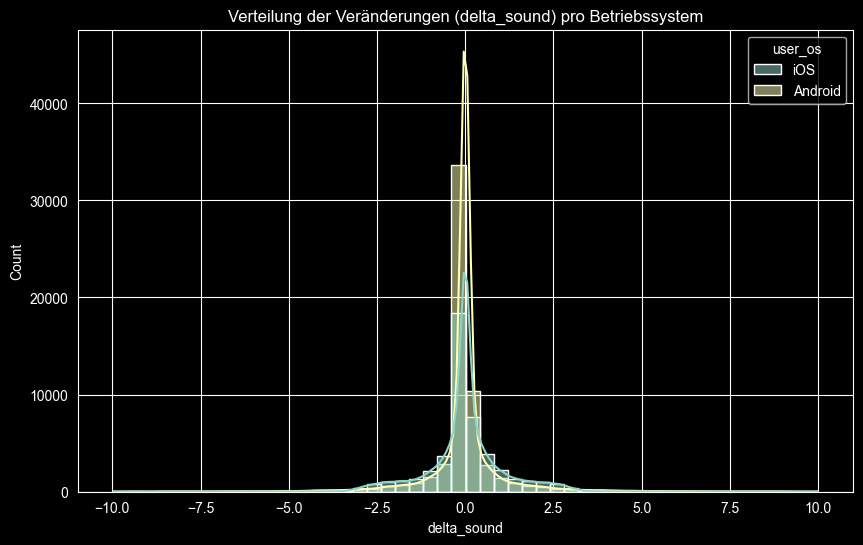

In [67]:
# Vergleich der Deltas -> zeigt, dass wir eine dynamische und keine fixe Schwelle brauchen
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='delta_sound', hue='user_os', kde=True, bins=50)
plt.title('Verteilung der Veränderungen (delta_sound) pro Betriebssystem')
plt.show()

## Einfluss verschiedener Faktoren auf *q1* Wert

In [68]:
# Idee hinter diesem Codeblock:
#   im nächsten Codeblock wird der Einfluss der Faktoren auf das Auftreten von q1 überprüft,
#   aber Zeilen, die fehlende Werte enthalten, werden gelöscht. Wenn ich die fehlenden Werte
#   davor auffülle, dann könnte das den Einfluss der Faktoren auf das Auftreten von q1 beeinflussen.
#   --> Ergebnis: Reihenfolge bleibt gleich. Beeinflussung um jeweils 1 Prozentpunkt.
#                 Daher kann man das vernachlässigen.

# Das Gleiche gilt für die Auswertung bei dem "Einfluss der Faktoren den Score"
# Dort sind es Veränderungen um jeweils 1-2 Prozentpunkte

'''
# Kontrolle wo noch fehlende Werte sind
df.isna().sum()

# Fehlende Score Werte mit dem Median ersetzen
# Median berechnen
median_score = df["score"].median()
# Fehlende Werte ersetzen
df["score"] = df["score"].fillna(median_score)
print(f"Eingesetzter Median (Score): {median_score}")

# Fehlende sound_norm Werte mit Median des jeweiligen OS ersetzen
df['sound_norm'] = df['sound_norm'].fillna(df.groupby('user_os')['sound_norm'].transform('median'))

# Fehlende Age Werte mit dem Median ersetzen
# Median berechnen
median_age = df["age"].median()
# Fehlende Werte ersetzen
df["age"] = df["age"].fillna(median_age)
print(f"Eingesetzter Median (Age): {median_age}")

# Fehlende Onsetduration Werte mit dem Median ersetzen
# Median berechnen
median_ons = df["onset_duration"].median()
# Fehlende Werte ersetzen
df["onset_duration"] = df["onset_duration"].fillna(median_ons)
print(f"Eingesetzter Median (Onsetduration): {median_ons}")

# Fehlende time_to_prev_event Werte mit 0 ersetzen
df["time_to_prev_event"] = df["time_to_prev_event"].fillna(0).astype(int)
'''

'\n# Kontrolle wo noch fehlende Werte sind\ndf.isna().sum()\n\n# Fehlende Score Werte mit dem Median ersetzen\n# Median berechnen\nmedian_score = df["score"].median()\n# Fehlende Werte ersetzen\ndf["score"] = df["score"].fillna(median_score)\nprint(f"Eingesetzter Median (Score): {median_score}")\n\n# Fehlende sound_norm Werte mit Median des jeweiligen OS ersetzen\ndf[\'sound_norm\'] = df[\'sound_norm\'].fillna(df.groupby(\'user_os\')[\'sound_norm\'].transform(\'median\'))\n\n# Fehlende Age Werte mit dem Median ersetzen\n# Median berechnen\nmedian_age = df["age"].median()\n# Fehlende Werte ersetzen\ndf["age"] = df["age"].fillna(median_age)\nprint(f"Eingesetzter Median (Age): {median_age}")\n\n# Fehlende Onsetduration Werte mit dem Median ersetzen\n# Median berechnen\nmedian_ons = df["onset_duration"].median()\n# Fehlende Werte ersetzen\ndf["onset_duration"] = df["onset_duration"].fillna(median_ons)\nprint(f"Eingesetzter Median (Onsetduration): {median_ons}")\n\n# Fehlende time_to_prev_e


--- Einfluss auf das Auftreten von Tinnitus (q1=1) ---
                            Feature  Gewichtung
2                        sound_norm    0.235986
0                                q1    0.201548
1                             score    0.133559
3                               age    0.126959
4                    onset_duration    0.092932
7   state_with_tinnitus_level 2_0.0    0.091495
9   state_with_tinnitus_level 3_0.0    0.031599
5                time_to_prev_event    0.028491
8   state_with_tinnitus_level 2_1.0    0.018803
10  state_with_tinnitus_level 3_1.0    0.017850


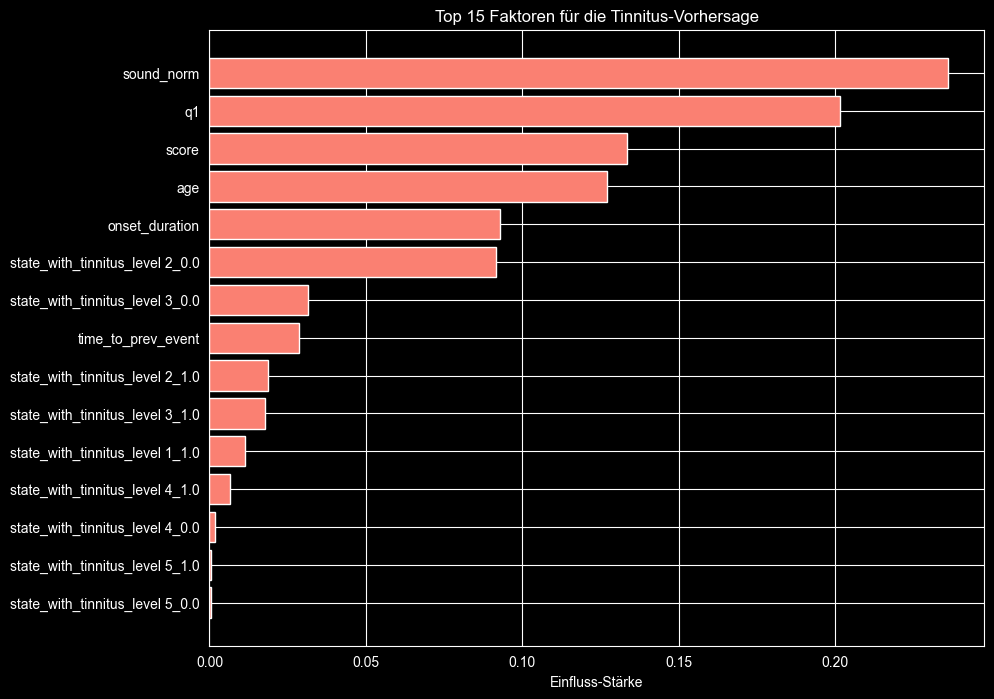

In [95]:
'''
# --> State_with_tinnitus hat deutlich weniger einfluss als score allein.

# --- Klassifikations-Analyse: Was beeinflusst das Tinnitus-Auftreten (next_q1)? ---

# 1. Daten vorbereiten
df['next_q1'] = df.groupby('user_id')['q1'].shift(-1)

# Features festlegen
features_clf = ["q1", "score", "state_with_tinnitus", "sound_norm", "age", "onset_duration", "time_to_prev_event"]
target_clf = "next_q1"

# Daten bereinigen
df_clf = df[features_clf + [target_clf]].dropna()

# 2. DER ENTSCHEIDENDE SCHRITT: One-Hot-Encoding für den String "state_with_tinnitus"
# Das wandelt "level 1_0.0" etc. in Spalten mit 0 und 1 um
X_raw = df_clf[features_clf]
X_clf = pd.get_dummies(X_raw, columns=["state_with_tinnitus"], drop_first=True)

y_clf = df_clf[target_clf].astype(int)

# 3. Random Forest Classifier trainieren
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_clf, y_clf)

# 4. Einflussfaktoren (Feature Importance)
# Da X_clf jetzt mehr Spalten hat (durch dummies), nehmen wir X_clf.columns
importances_clf = pd.DataFrame({
    "Feature": X_clf.columns,
    "Gewichtung": clf.feature_importances_
}).sort_values(by="Gewichtung", ascending=False)

print("\n--- Einfluss auf das Auftreten von Tinnitus (q1=1) ---")
print(importances_clf.head(10)) # Top 10 anzeigen

# 5. Visualisierung
plt.figure(figsize=(10, 8))
# Wir plotten nur die Top 15, falls es durch die Dummies zu viele geworden sind
top_n = 15
plt.barh(importances_clf["Feature"].head(top_n), importances_clf["Gewichtung"].head(top_n), color="salmon")
plt.xlabel("Einfluss-Stärke")
plt.title(f"Top {top_n} Faktoren für die Tinnitus-Vorhersage")
plt.gca().invert_yaxis()
plt.show()
'''

'''
Output:

--- Einfluss auf das Auftreten von Tinnitus (q1=1) ---
                            Feature  Gewichtung
2                        sound_norm    0.235986
0                                q1    0.201548
1                             score    0.133559
3                               age    0.126959
4                    onset_duration    0.092932
7   state_with_tinnitus_level 2_0.0    0.091495
9   state_with_tinnitus_level 3_0.0    0.031599
5                time_to_prev_event    0.028491
8   state_with_tinnitus_level 2_1.0    0.018803
10  state_with_tinnitus_level 3_1.0    0.017850
'''

In [96]:
'''
# state_with_tinnitus als einzelne Spalte werten
# --> State_with_tinnitus hat nach wie vor deutlich weniger einfluss als score allein.

from sklearn.preprocessing import LabelEncoder

# 1. Kopie der Daten
X_clf_simple = df_clf[features_clf].copy()

# 2. Text-Spalte in Zahlen umwandeln (0, 1, 2, 3...)
le = LabelEncoder()
X_clf_simple["state_with_tinnitus"] = le.fit_transform(X_clf_simple["state_with_tinnitus"])

# 3. Model trainieren
clf_simple = RandomForestClassifier(n_estimators=100, random_state=42)
clf_simple.fit(X_clf_simple, y_clf)

# 4. Importance anzeigen
importances_simple = pd.DataFrame({
    "Feature": features_clf,
    "Gewichtung": clf_simple.feature_importances_
}).sort_values(by="Gewichtung", ascending=False)

print(importances_simple)
'''

'''
Output:

               Feature  Gewichtung
0                   q1    0.275165
3           sound_norm    0.234711
1                score    0.150326
4                  age    0.123188
2  state_with_tinnitus    0.095111
5       onset_duration    0.091008
6   time_to_prev_event    0.030491
'''

               Feature  Gewichtung
0                   q1    0.275165
3           sound_norm    0.234711
1                score    0.150326
4                  age    0.123188
2  state_with_tinnitus    0.095111
5       onset_duration    0.091008
6   time_to_prev_event    0.030491



--- Einfluss auf das Auftreten von Tinnitus (q1=1) ---
              Feature  Gewichtung
0                  q1    0.372145
2          sound_norm    0.230950
1               score    0.163477
3                 age    0.116526
4      onset_duration    0.086661
5  time_to_prev_event    0.030241


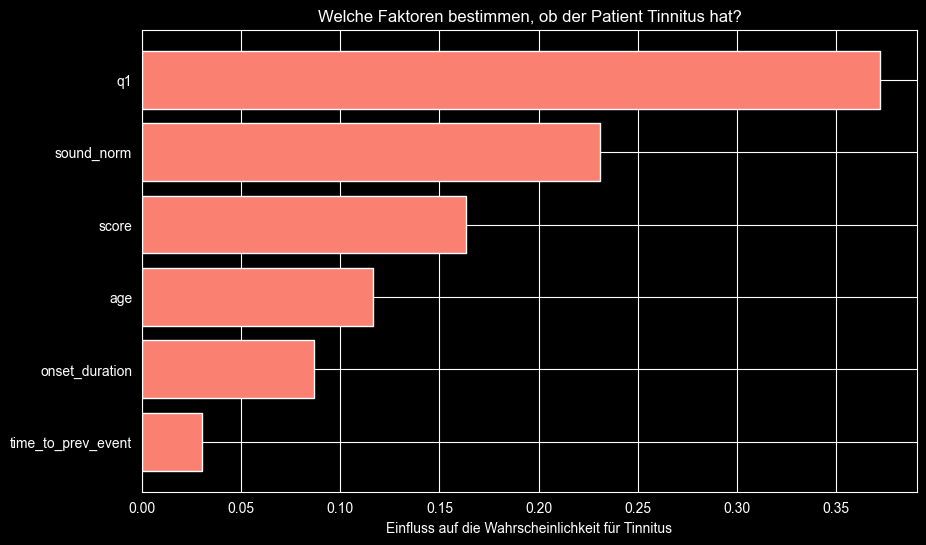

In [98]:
# Klassifikations-Analyse: Was beeinflusst das Tinnitus-Auftreten (q1)?

# Daten vorbereiten
# Wir wollen vorhersagen, ob q1 beim NÄCHSTEN Termin '1' ist (Tinnitus vorhanden)
df['next_q1'] = df.groupby('user_id')['q1'].shift(-1)

# Features: Wir nutzen den Score, Sound, Alter, etc. von HEUTE
features_clf = ["q1", "score", "sound_norm", "age", "onset_duration", "time_to_prev_event"] # "after_noise_burst" auch dazu?
target_clf = "next_q1"

# Daten bereinigen (nur vollständige Zeilen für Klassifikation)
df_clf = df[features_clf + [target_clf]].dropna()
X_clf = df_clf[features_clf]
y_clf = df_clf[target_clf].astype(int)  # Sicherstellen, dass es 0 oder 1 ist

# Random Forest Classifier trainieren
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_clf, y_clf)

# Einflussfaktoren (Feature Importance)
importances_clf = pd.DataFrame({
    "Feature": features_clf,
    "Gewichtung": clf.feature_importances_
}).sort_values(by="Gewichtung", ascending=False)

print("\n--- Einfluss auf das Auftreten von Tinnitus (q1=1) ---")
print(importances_clf)

# Visualisierung der Einflussfaktoren
plt.figure(figsize=(10, 6))
plt.barh(importances_clf["Feature"], importances_clf["Gewichtung"], color="salmon")
plt.xlabel("Einfluss auf die Wahrscheinlichkeit für Tinnitus")
plt.title("Welche Faktoren bestimmen, ob der Patient Tinnitus hat?")
plt.gca().invert_yaxis()
plt.show()

### Einfluss von *state_with_tinnitus* auf *q1*

In [100]:
# Wahrscheinlichkeiten berechnen

# Daten vorbereiten
df_state_analysis = df.dropna(subset=['state_with_tinnitus', 'next_q1']).copy()

# Gruppierte Wahrscheinlichkeiten berechnen
# Wir gruppieren nach dem kombinierten Zustand und schauen uns den Durchschnitt von next_q1 an
state_probs = df_state_analysis.groupby('state_with_tinnitus')['next_q1'].agg(['mean', 'count']).reset_index()

# Umrechnung in Prozent
state_probs['mean'] = state_probs['mean'] * 100
state_probs.columns = ['Zustand (heute)', 'Wahrscheinlichkeit_Tinnitus_morgen_%', 'Anzahl_Fälle']

# Sortieren nach Wahrscheinlichkeit
state_probs = state_probs.sort_values(by='Wahrscheinlichkeit_Tinnitus_morgen_%', ascending=False)

print("--- Wahrscheinlichkeit für Tinnitus im nächsten Schritt nach aktuellem Zustand ---")
print(state_probs.to_string(index=False))

--- Wahrscheinlichkeit für Tinnitus im nächsten Schritt nach aktuellem Zustand ---
Zustand (heute)  Wahrscheinlichkeit_Tinnitus_morgen_%  Anzahl_Fälle
    level 5_1.0                             96.325167           898
    level 4_1.0                             94.771358          5642
    level 3_1.0                             94.412595         35759
    level 1_1.0                             91.986360          9384
    level 2_1.0                             90.582946         33811
    level 1_0.0                             33.813295          4167
    level 2_0.0                             29.374105         11871
    level 3_0.0                             23.418768          4838
    level 4_0.0                             19.178082           438
    level 5_0.0                             12.962963            54


In [102]:
# Signifikanz berechnen

# Kontingenztabelle erstellen
# Zeilen: Kombinierter Zustand heute, Spalten: Tinnitus morgen (0 oder 1)
contingency_table_state = pd.crosstab(
    df_state_analysis['state_with_tinnitus'],
    df_state_analysis['next_q1']
)

print("\n--- Kontingenztabelle: Zustand heute vs. next_q1 Morgen ---")
print(contingency_table_state)


--- Kontingenztabelle: Zustand heute vs. next_q1 Morgen ---
next_q1               0.0    1.0
state_with_tinnitus             
level 1_0.0          2758   1409
level 1_1.0           752   8632
level 2_0.0          8384   3487
level 2_1.0          3184  30627
level 3_0.0          3705   1133
level 3_1.0          1998  33761
level 4_0.0           354     84
level 4_1.0           295   5347
level 5_0.0            47      7
level 5_1.0            33    865


In [103]:
# Chi-Quadrat-Test
chi2, p_val, dof, expected = chi2_contingency(contingency_table_state)

print(f"\n--- Signifikanz-Analyse: Einfluss des Zustands-Mix ---")
print(f"Chi-Quadrat: {chi2:.2f}")
print(f"p-Wert: {p_val:.4e}")

if p_val < 0.05:
    print("Ergebnis: Statistisch hochsignifikant (Die Kombination aus Level und Tinnitus beeinflusst den Folgestatus).")
else:
    print("Ergebnis: Nicht signifikant.")


--- Signifikanz-Analyse: Einfluss des Zustands-Mix ---
Chi-Quadrat: 43973.96
p-Wert: 0.0000e+00
Ergebnis: Statistisch hochsignifikant (Die Kombination aus Level und Tinnitus beeinflusst den Folgestatus).


### Einfluss von *q1* auf *q1*

In [70]:
# Wahrscheinlichkeiten berechnen

# Wir betrachten nur die Fälle, bei denen wir den Vorher-Nachher-Status kennen
df_q1_analysis = df.dropna(subset=['q1', 'next_q1']).copy()

# Wahrscheinlichkeit für Tinnitus im nächsten Eintrag, gegeben der aktuelle Status (q1)
# Wir teilen die Daten in: Heute Tinnitus (q1=1) und Heute kein Tinnitus (q1=0)
status_0 = df_q1_analysis[df_q1_analysis['q1'] == 0]
status_1 = df_q1_analysis[df_q1_analysis['q1'] == 1]

prob_tinnitus_from_0 = status_0['next_q1'].mean() * 100
prob_tinnitus_from_1 = status_1['next_q1'].mean() * 100

print(f"--- Tinnitus-Verlaufs-Analyse ---")
print(f"Wahrscheinlichkeit für Tinnitus-Auftreten (q1=0 -> q1=1): {prob_tinnitus_from_0:.2f}%")
print(f"Wahrscheinlichkeit für Tinnitus-Persistenz (q1=1 -> q1=1): {prob_tinnitus_from_1:.2f}%")
print(f"\nAnzahl untersuchter Fälle (q1=0): {len(status_0)}")
print(f"Anzahl untersuchter Fälle (q1=1): {len(status_1)}")

# Zum Vergleich: Der "Lift" durch Tinnitus heute
# Wie viel wahrscheinlicher ist Tinnitus morgen, wenn ich heute schon welchen habe?
lift = prob_tinnitus_from_1 / prob_tinnitus_from_0
print(f"\nDer Patient ist beim heutigen Tinnitus-Status '= 1' {lift:.2f}-mal wahrscheinlicher morgen wieder betroffen.")

--- Tinnitus-Verlaufs-Analyse ---
Wahrscheinlichkeit für Tinnitus-Auftreten (q1=0 -> q1=1): 28.64%
Wahrscheinlichkeit für Tinnitus-Persistenz (q1=1 -> q1=1): 92.68%

Anzahl untersuchter Fälle (q1=0): 21368
Anzahl untersuchter Fälle (q1=1): 85494

Der Patient ist beim heutigen Tinnitus-Status '= 1' 3.24-mal wahrscheinlicher morgen wieder betroffen.


In [71]:
# Signifikanz berechnen

# Kontingenztabelle erstellen
# Zeilen: Status Heute (q1=0 oder 1), Spalten: Status Morgen (next_q1=0 oder 1)
contingency_table_q1 = pd.crosstab(
    df_q1_analysis['q1'],
    df_q1_analysis['next_q1']
)

print("\n--- Kontingenztabelle: q1 Heute vs. next_q1 Morgen ---")
print(contingency_table_q1)

# Chi-Quadrat-Test
chi2, p_val, dof, expected = chi2_contingency(contingency_table_q1)

print(f"\n--- Signifikanz-Analyse: Tinnitus-Persistenz ---")
print(f"Chi-Quadrat: {chi2:.2f}")
print(f"p-Wert: {p_val:.4e}") # wissenschaftliche Notation, da extrem klein

if p_val < 0.05:
    print("Ergebnis: Statistisch hochsignifikant (Der Status heute bestimmt den Status morgen).")
else:
    print("Ergebnis: Nicht signifikant.")


--- Kontingenztabelle: q1 Heute vs. next_q1 Morgen ---
next_q1    0.0    1.0
q1                   
0.0      15248   6120
1.0       6262  79232

--- Signifikanz-Analyse: Tinnitus-Persistenz ---
Chi-Quadrat: 43597.12
p-Wert: 0.0000e+00
Ergebnis: Statistisch hochsignifikant (Der Status heute bestimmt den Status morgen).


### Einfluss von *Lärm* auf *q1*
Lärm = noise_burst_cases

In [72]:
# Wahrscheinlichkeiten berechnen

# Tinnitus-Veränderung (Delta q1)
# q1 ist binär (0 oder 1). Wenn q1 von 0 auf 1 wechselt, ist das eine Verschlechterung.
df['delta_q1'] = df.groupby('user_id')['q1'].diff()
df['next_delta_q1'] = df.groupby('user_id')['delta_q1'].shift(-1)

# Analyse: Wie oft entsteht Tinnitus (q1=1) nach einer Lärm-Verschlechterung?
# Wir schauen uns nur Fälle an, wo es vorher KEIN Tinnitus gab (q1=0)
no_tinnitus_before = df[df['q1'] == 0].copy()
noise_burst_cases = no_tinnitus_before[no_tinnitus_before['after_noise_burst'] == True]

# Berechne den Anteil der Fälle, in denen Tinnitus beim nächsten Event auftrat
tinnitus_onset_rate = noise_burst_cases['next_q1'].mean() * 100

print(f"--- Tinnitus-Auftreten-Analyse nach Lärm ---")
print(f"Wahrscheinlichkeit für Tinnitus-Auftreten nach Lärm (bei Patienten ohne Tinnitus): {tinnitus_onset_rate:.2f}%")
print(f"Anzahl untersuchter Fälle: {len(noise_burst_cases)}")

--- Tinnitus-Auftreten-Analyse nach Lärm ---
Wahrscheinlichkeit für Tinnitus-Auftreten nach Lärm (bei Patienten ohne Tinnitus): 30.14%
Anzahl untersuchter Fälle: 1023


In [73]:
# Signifikanz berechnen

# Daten filtern: Nur Fälle, in denen vorher KEIN Tinnitus (q1=0) vorlag
df_no_tinnitus = df[df['q1'] == 0].copy()

# Kontingenztabelle erstellen
# Zeilen: Lärm-Ereignis (Ja/Nein), Spalten: Tinnitus-Status beim nächsten Eintrag (0/1)
# Wir nutzen next_q1, das wir es vorher definiert haben
contingency_table_tinnitus = pd.crosstab(
    df_no_tinnitus['after_noise_burst'],
    df_no_tinnitus['next_q1']
)

print("\n--- Kontingenztabelle: Lärm vs. Tinnitus-Auftreten ---")
print(contingency_table_tinnitus)

# Chi-Quadrat-Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table_tinnitus)

print(f"\n--- Signifikanz-Analyse: Lärm -> Tinnitus-Auftreten ---")
print(f"Chi-Quadrat: {chi2:.2f}")
print(f"p-Wert: {p_value:.4f}")

if p_value < 0.05:
    print("Ergebnis: Signifikanter Zusammenhang zwischen Lärm und Tinnitus-Auftreten.")
else:
    print("Ergebnis: Kein signifikanter Zusammenhang nachweisbar.")


--- Kontingenztabelle: Lärm vs. Tinnitus-Auftreten ---
next_q1              0.0   1.0
after_noise_burst             
False              14548  5818
True                 700   302

--- Signifikanz-Analyse: Lärm -> Tinnitus-Auftreten ---
Chi-Quadrat: 1.08
p-Wert: 0.2987
Ergebnis: Kein signifikanter Zusammenhang nachweisbar.


In [74]:
# Ohne Lärm (False): Von 20.366 Fällen (14.548 + 5.818) traten bei 5.818 Tinnitus auf. Das entspricht einer Quote von ca. 39,9 %.
# Mit Lärm (True): Von 1.002 Fällen (700 + 302) traten bei 302 Tinnitus auf. Das entspricht einer Quote von ca. 43,1 %.

# Tinnitus-Rate mit Lärm (43,1%) höher als Tinnitus-Rate ohne Lärm (39,9%).

# Mögliche Interpretation:
# Im Datensatz lässt sich kein statistisch belastbarer Zusammenhang zwischen einer vorangegangenen Lärmexposition (Noise Burst)
# und dem unmittelbaren Auftreten von Tinnitus (next_q1) nachweisen.

# Mögliche Gründe für das Ausbleiben der Signifikanz:
# 1. Kompensationseffekte: Individuelle Maskierungseffekte (Linderung durch Lärm) und Triggereffekte (Verschlechterung durch Lärm)
#    könnten sich im Gesamtdatensatz gegenseitig aufheben.
# 2. Zeitlicher Verzug: Die Reaktion auf einen Noise Burst erfolgt möglicherweise nicht unmittelbar beim nächsten Event, sondern
#    zeitversetzt oder über einen längeren Akkumulationszeitraum.
# 3. Stichprobengröße: Obwohl über 1.000 Lärm-Events vorliegen, ist der relative Anteil am Gesamtdatensatz gering, was die
#    Entdeckung kleiner Effekte erschwert.

# Fazit: Lärm scheint in dieser Kohorte kein universeller Prädiktor für das kurzfristige Tinnitus-Status-Update zu sein.

In [75]:
# den Part würde ich eher vernachlässigen /rausschmeißen

# Wahrscheinlichkeit berechnen (frische und chronische Patienten)

# Vergleich der Auftrete-Rate zwischen 'Frisch' und 'Chronisch'
onset_median = df['onset_duration'].median()

fresh_patients = noise_burst_cases[noise_burst_cases['onset_duration'] <= onset_median]
chronic_patients = noise_burst_cases[noise_burst_cases['onset_duration'] > onset_median]

print(f"\n--- Vergleich: Tinnitus-Auftreten nach Lärm ---")
print(f"Tinnitus-Auftreten bei 'frischen' Fällen: {(fresh_patients['next_q1'].mean() * 100):.2f}%")
print(f"Tinnitus-Auftreten bei 'chronischen' Fällen: {(chronic_patients['next_q1'].mean() * 100):.2f}%")


--- Vergleich: Tinnitus-Auftreten nach Lärm ---
Tinnitus-Auftreten bei 'frischen' Fällen: 36.35%
Tinnitus-Auftreten bei 'chronischen' Fällen: 26.46%


In [76]:
# den Part würde ich eher vernachlässigen /rausschmeißen

# Signifikanz berechnen (frische und chronische Patienten)

# Kontingenztabelle erstellen
# Wir bauen eine Tabelle: [Tinnitus=0, Tinnitus=1] für [Frisch, Chronisch]
contingency_table = pd.crosstab(
    index=pd.concat([fresh_patients['next_q1'], chronic_patients['next_q1']]),
    columns=[['Frisch']*len(fresh_patients) + ['Chronisch']*len(chronic_patients)]
).T

# Falls die Tabelle die falsche Form hat (Rows/Cols), korrigieren wir sie kurz:
# Spalten: Tinnitus=0, Tinnitus=1; Zeilen: Gruppe
tab = pd.DataFrame({
    'No_Tinnitus': [len(fresh_patients[fresh_patients['next_q1']==0]), len(chronic_patients[chronic_patients['next_q1']==0])],
    'Tinnitus': [len(fresh_patients[fresh_patients['next_q1']==1]), len(chronic_patients[chronic_patients['next_q1']==1])]
}, index=['Frisch', 'Chronisch'])

print(contingency_table)

# Chi-Quadrat-Test
chi2, p_val, dof, expected = chi2_contingency(tab)

print(f"\n--- Korrekte Signifikanz-Analyse (Chi-Quadrat) ---")
print(f"p-Wert: {p_val:.4f}")

if p_val < 0.05:
    print("Ergebnis: Statistisch signifikant (Die Gruppen reagieren unterschiedlich).")
else:
    print("Ergebnis: Nicht signifikant (Der Unterschied ist zufällig).")

next_q1    0.0  1.0
col_0              
Chronisch  264   95
Frisch     324  185

--- Korrekte Signifikanz-Analyse (Chi-Quadrat) ---
p-Wert: 0.0028
Ergebnis: Statistisch signifikant (Die Gruppen reagieren unterschiedlich).


In [77]:
# Es gibt einen stark signifikanten Zusammenhang zwischen der Erkrankungsdauer (frisch vs. chronisch) und der Wahrscheinlichkeit,
# nach einer Lärmexposition einen Tinnitus-Auftreten zu erleben.

### Einfluss von *score* auf *q1*

In [78]:
# Wahrscheinlichkeiten berechnen

df_clf['score_bins'] = pd.cut(df_clf['score'], bins=[0, 17, 34, 50], labels=["low", "medium", "high"])
prob_table = df_clf.groupby('score_bins', observed=True)['next_q1'].mean() * 100

print("\n--- Wahrscheinlichkeit für Tinnitus-Auftreten je Score-Level ---")
print(prob_table.map("{:.2f}%".format))


--- Wahrscheinlichkeit für Tinnitus-Auftreten je Score-Level ---
score_bins
low       74.18%
medium    86.05%
high      92.75%
Name: next_q1, dtype: str


In [79]:
# Signifikanz berechnen

# Kontingenztabelle für Score-Level vs. Tinnitus-Auftreten (next_q1)
contingency_table_score = pd.crosstab(
    df_clf['score_bins'],
    df_clf['next_q1']
)

print("\n--- Kontingenztabelle: Score-Level vs. Tinnitus-Auftreten (next_q1) ---")
print(contingency_table_score)

# Chi-Quadrat-Test
chi2, p_val, dof, expected = chi2_contingency(contingency_table_score)

print(f"\n--- Signifikanz-Analyse: Score-Einfluss ---")
print(f"Chi-Quadrat: {chi2:.2f}")
print(f"p-Wert: {p_val:.4e}")

if p_val < 0.05:
    print("Ergebnis: Statistisch hochsignifikant (Der Score-Level beeinflusst das Tinnitus-Risiko am nächsten Tag).")
else:
    print("Ergebnis: Nicht signifikant.")


--- Kontingenztabelle: Score-Level vs. Tinnitus-Auftreten (next_q1) ---
next_q1      0.0    1.0
score_bins             
low         9554  27446
medium      7773  47945
high         220   2815

--- Signifikanz-Analyse: Score-Einfluss ---
Chi-Quadrat: 2350.42
p-Wert: 0.0000e+00
Ergebnis: Statistisch hochsignifikant (Der Score-Level beeinflusst das Tinnitus-Risiko am nächsten Tag).


In [80]:
# Low: 59.430/(13.622+45.808)≈77,1% Risiko für Tinnitus-Auftreten.
# Medium: 35.595/(3.706+31.889)≈89,6% Risiko für Tinnitus-Auftreten.
# High: 288/(17+271)≈94,1% Risiko für Tinnitus-Auftreten.

## Einfluss verschiedener Faktoren auf *score* Wert

### Teil 1


--- Statistische Gewichtung der Features ---
                Feature  Gewichtung
2            prev_score    0.577749
3            sound_norm    0.184369
0                   age    0.099603
4        onset_duration    0.081867
6    time_to_prev_event    0.036614
5                    q1    0.019327
1  missing_demographics    0.000471


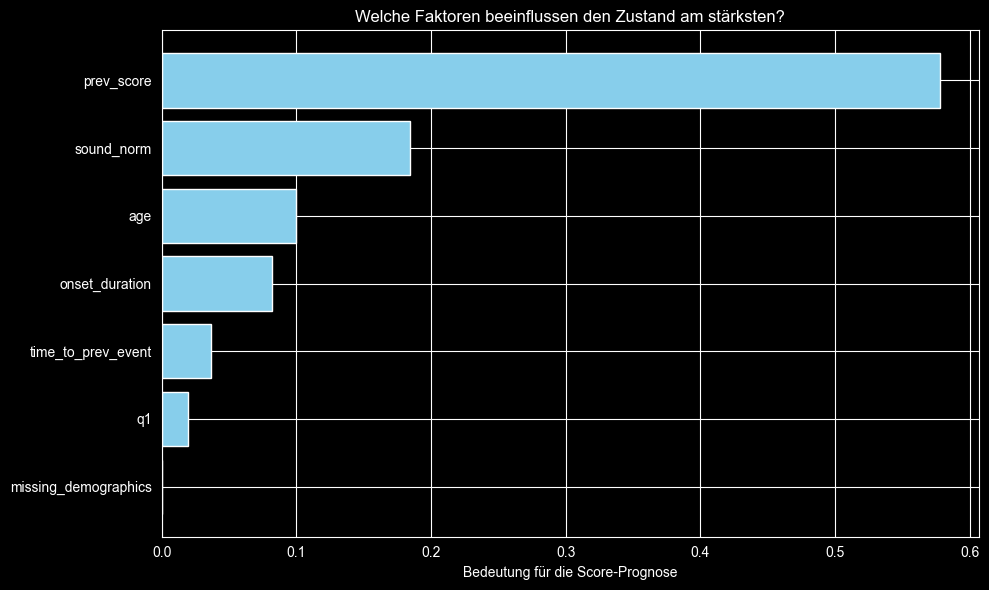

In [81]:
# Modell trainieren, um Stärke der Einflussfaktoren zu identifizieren.
# Neue Variante / neu hinzugefügt

# Daten vorbereiten
df['prev_score'] = df.groupby('user_id')['score'].shift(1)
features_new = ["age", "missing_demographics", "prev_score", "sound_norm", "onset_duration", "q1", "time_to_prev_event"] # relevante Spalten für Analyse

target = "score"

# Daten bereinigen
df_clean = df[features_new + [target]].dropna() # <- hier könnte man gewisse Werte vorher mit missing data strategie auffüllen
X = df_clean[features_new]
y = df_clean[target]

# Modell definieren und trainieren
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Gewichte extrahieren
importances = pd.DataFrame({
    "Feature": features_new,
    "Gewichtung": model.feature_importances_
}).sort_values(by="Gewichtung", ascending=False)

print("\n--- Statistische Gewichtung der Features ---")
print(importances)

# Visualisierung der Einflussfaktoren
plt.figure(figsize=(10, 6))
plt.barh(importances["Feature"], importances["Gewichtung"], color="skyblue")
plt.xlabel("Bedeutung für die Score-Prognose")
plt.title("Welche Faktoren beeinflussen den Zustand am stärksten?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [82]:
# prev_score zeigt, dass ohne ihn der Score im kommenden Event 59,4% schlechter vorhergesagt werden könnte.
# sound_norm zeigt, dass ohne ihn der Score im kommenden Event 17,7% schlechter vorhergesagt werden könnte.

# --> ist der prev_score wirklich der Grund für den kommenden Score? Oder ist es eher sound_norm? Man könnte sagen, das die Lösung darin liegt, den Score zu reduzieren.

In [111]:
'''
# --> State_with_tinnitus hat deutlich weniger einfluss als prev_score allein.

# Erstellt eine neue Spalte mit dem Zustand des vorherigen Events
df['prev_state_with_tinnitus'] = df.groupby('user_id')['state_with_tinnitus'].shift(1)

# Dann in den Features ersetzen:
features = [
    "age", "q1", "sound_norm", "prev_state_with_tinnitus", ...
]

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

# 1. Relevante Spalten auswählen
features = ["age","missing_demographics","prev_state_with_tinnitus","sound_norm","onset_duration", "q1", "time_to_prev_event"]

target = "score"

# 2. Daten bereinigen
analysis_df = df[features + [target]].dropna().copy()

# 3. state_with_tinnitus in Zahlen umwandeln
# Da RandomForest nicht mit Strings arbeiten kann
le = LabelEncoder()
analysis_df["prev_state_with_tinnitus"] = le.fit_transform(analysis_df["prev_state_with_tinnitus"])

# 4. Modell definieren und trainieren
model = RandomForestRegressor(n_estimators=100, random_state=42)

X = analysis_df[features]
y = analysis_df[target]
model.fit(X, y)

# 5. Gewichte extrahieren
importances = pd.DataFrame({
    "Feature": features,
    "Gewichtung": model.feature_importances_
}).sort_values(by="Gewichtung", ascending=False)

print("\n--- Statistische Gewichtung der Features (inkl. Zustand) ---")
print(importances)
'''

'''
Output:

--- Statistische Gewichtung der Features (inkl. Zustand) ---
                    Feature  Gewichtung
2  prev_state_with_tinnitus    0.487050
3                sound_norm    0.251052
0                       age    0.106933
4            onset_duration    0.094424
6        time_to_prev_event    0.040046
5                        q1    0.020164
1      missing_demographics    0.000331
'''


--- Statistische Gewichtung der Features (inkl. Zustand) ---
                    Feature  Gewichtung
2  prev_state_with_tinnitus    0.487050
3                sound_norm    0.251052
0                       age    0.106933
4            onset_duration    0.094424
6        time_to_prev_event    0.040046
5                        q1    0.020164
1      missing_demographics    0.000331


### Teil 2

In [107]:
# Modell trainieren, um Stärke der Einflussfaktoren zu identifizieren.

# Nur relevante Spalten für die Analyse auswählen
features = [
    "age", "q1", "time_to_prev_event",
    "sound_norm", "missing_demographics", "onset_duration"
]

# Zielvariable (der aktuelle Score)
target = "score"

# Daten bereinigen: Nur Zeilen ohne NaNs in diesen Spalten nutzen
analysis_df = df[features + [target]].dropna() # <- hier könnte man gewisse Werte vorher mit missing data strategie auffüllen

# Falls user_OS noch ein String ist, für die Analyse in Zahlen umwandeln
# analysis_df["user_OS_coded"] = pd.factorize(df["user_OS"])[0]

# Modell definieren
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Training
X = analysis_df[features]
y = analysis_df[target]
model.fit(X, y)

# Gewichte extrahieren
importances = pd.DataFrame({
    "Feature": features,
    "Gewichtung": model.feature_importances_
}).sort_values(by="Gewichtung", ascending=False)

print("\n--- Statistische Gewichtung der Features ---")
print(importances)


--- Statistische Gewichtung der Features ---
                Feature  Gewichtung
3            sound_norm    0.408174
0                   age    0.271252
5        onset_duration    0.204074
1                    q1    0.061674
2    time_to_prev_event    0.054402
4  missing_demographics    0.000425


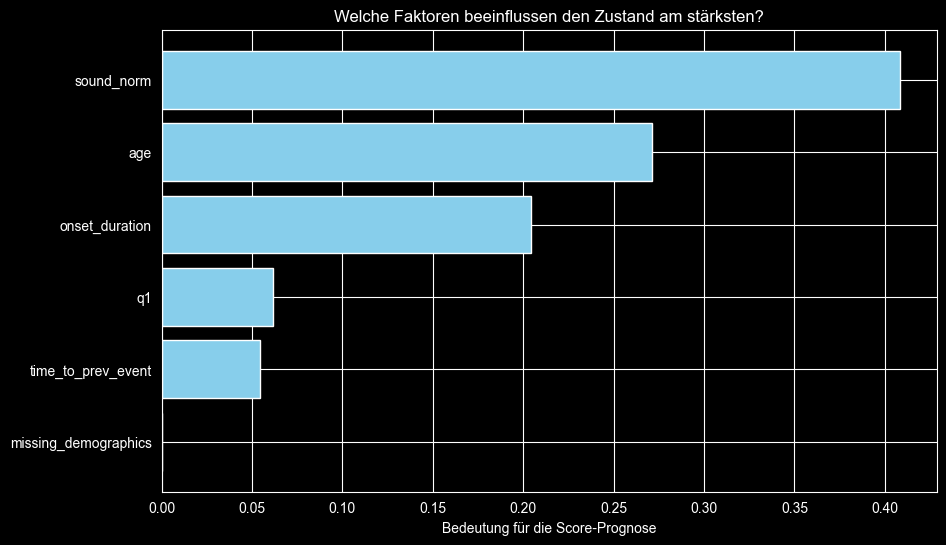

In [105]:
# Visualisierung der Einflussfaktoren
plt.figure(figsize=(10, 6))
plt.barh(importances["Feature"], importances["Gewichtung"], color="skyblue")
plt.xlabel("Bedeutung für die Score-Prognose")
plt.title("Welche Faktoren beeinflussen den Zustand am stärksten?")
plt.gca().invert_yaxis()
plt.show()

In [85]:
# --> missing_demographics hat keinen Einfluss. Könnte man auch von Beginn an rausnehmen.

# sound_norm zeigt, dass ohne ihn der Score im kommenden Event 39,3% schlechter vorhergesagt werden könnte.

In [86]:
analysis_df

,age,q1,time_to_prev_event,sound_norm,missing_demographics,onset_duration,score
1,35.0,1.0,4.0,1.310227,False,4.0,30.0
2,35.0,0.0,1.0,1.250036,False,4.0,9.0
3,35.0,0.0,0.0,-0.277007,False,4.0,31.5
4,35.0,0.0,23.0,0.875239,False,4.0,1.0
5,36.0,1.0,373.0,1.827533,False,5.0,14.5
...,...,...,...,...,...,...,...
112181,60.0,1.0,2.0,-0.413885,False,1.0,41.0
112182,60.0,1.0,2.0,-0.167038,False,1.0,38.5
112183,60.0,1.0,251.0,-0.039594,False,1.0,29.0
112186,33.0,1.0,146.0,-1.580506,False,1.0,29.5


#### Einfluss von *Lärm* auf *score*
Lärm = after_noise_burst

In [87]:
# Prüfe die Korrelation zwischen Sound und Score im Detail
print(f"Korrelation Sound/Score: {analysis_df['sound_norm'].corr(analysis_df['score']):.3f}")

# Schau dir den durchschnittlichen Score in Sound-Quantilen an
analysis_df['sound_bins'] = pd.qcut(analysis_df['sound_norm'], q=5)
print(analysis_df.groupby('sound_bins')[target].mean())

Korrelation Sound/Score: 0.012
sound_bins
(-3.638, -0.497]    19.242887
(-0.497, -0.444]    19.860574
(-0.444, -0.186]    19.435197
(-0.186, 0.626]     19.424599
(0.626, 9.719]      19.266535
Name: score, dtype: float64


--- Schwellenwert Analyse: Sound vs. Score ---
         sound_bins      score
0  (-3.638, -0.831]  19.080712
1  (-0.831, -0.497]  19.228654
2  (-0.497, -0.444]  19.949217
3   (-0.444, -0.35]  19.553073
4   (-0.35, -0.177]  19.140833
5   (-0.177, 0.102]  19.203908
6    (0.102, 0.675]  19.290333
7    (0.675, 1.251]  18.109909
8    (1.251, 9.719]  19.583904


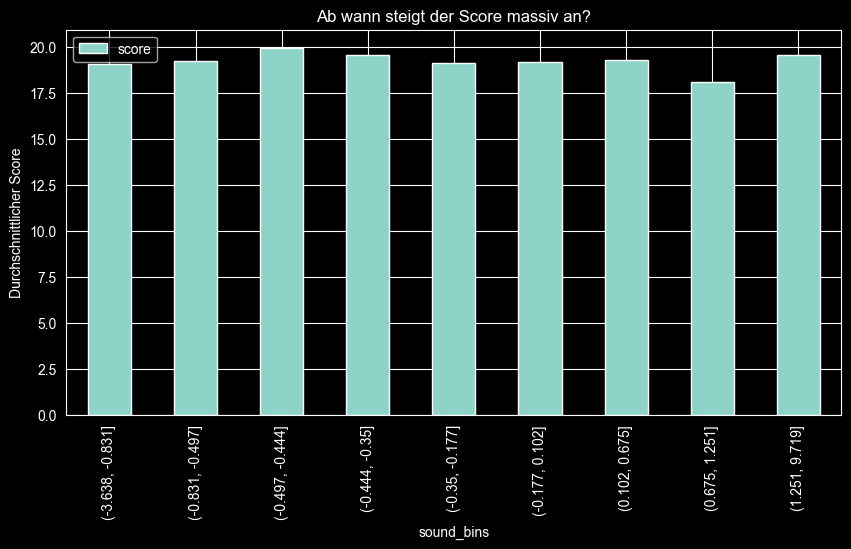

In [88]:
# Sound-Daten in 10 gleich große Gruppen unterteilen (Dezile)
df['sound_bins'] = pd.qcut(df['sound_norm'], q=10, duplicates='drop')

# Durchschnittlichen Score pro Gruppe berechnen
threshold_analysis = df.groupby('sound_bins', observed=True)['score'].mean().reset_index()

print("--- Schwellenwert Analyse: Sound vs. Score ---")
print(threshold_analysis)

# Visualisierung
threshold_analysis.plot(kind='bar', x='sound_bins', y='score', figsize=(10,5))
plt.title("Ab wann steigt der Score massiv an?")
plt.ylabel("Durchschnittlicher Score")
plt.show()

In [89]:
# Veränderungen berechnen (Delta)
# --> bereits i den "Vorbereitungen" erledigt (Anfang von diesem Teil - Feature Engineering und statistische Analyse)

# Den nächsten Score-Schritt an die aktuelle Zeile ziehen (Shift -1)
# Wir wollen wissen: Wenn Sound JETZT steigt, was macht der Score beim NÄCHSTEN Mal?
df['next_delta_score'] = df.groupby('user_id')['delta_score'].shift(-1)

# Zeitabstand zum nächsten Event berechnen
df['days_to_next'] = df.groupby('user_id')['time_to_prev_event'].shift(-1)

# Filter: Nur Fälle, in denen sich der Sound signifikant verschlechtert hat (z.B. Delta > 5%. Kann aber auch 3% oder 7% sein - os_thresholds oben definiert auf 5%)
deterioration = df[df['delta_sound'] > os_thresholds].copy()

print("--- Analyse bei Sound-Verschlechterung ---")
print(f"Anzahl gefundener 'Bursts': {len(deterioration)}")
print(f"\nDurchschnittliche Score-Änderung beim nächsten Termin: {deterioration['next_delta_score'].mean():.2f}")
print(f"Mittlerer Zeitabstand bis zur Score-Reaktion (Tage): {deterioration['days_to_next'].mean():.1f}")

--- Analyse bei Sound-Verschlechterung ---
Anzahl gefundener 'Bursts': 5323

Durchschnittliche Score-Änderung beim nächsten Termin: 0.14
Mittlerer Zeitabstand bis zur Score-Reaktion (Tage): 3.2


In [90]:
# Prüfen, wie oft ein Sound-Delta (>5%) zu einem Zustandswechsel führt
df['next_concept'] = df.groupby('user_id')['concept:name'].shift(-1)
df['state_changed'] = df['concept:name'] != df['next_concept']

# Filter auf Verschlechterung
det_change = df[df['delta_sound'] > os_thresholds]

change_rate = det_change['state_changed'].mean() * 100
print(f"Wahrscheinlichkeit eines Zustandswechsels nach Lärm: {change_rate:.2f}%")

Wahrscheinlichkeit eines Zustandswechsels nach Lärm: 45.71%


In [91]:
# Flag setzen: War das vorherige Event eine Sound-Verschlechterung?
# --> bereits in den Vorbereitungen erledigt

# Wir erstellen zwei Dataframes für den Vergleich
df_noise = df[df['after_noise_burst'] == True].copy()
df_stable = df[df['after_noise_burst'] == False].copy()

In [92]:
def get_dfg(dataframe):
    log_df = dataframe.copy()
    log_df = log_df.rename(columns={
        "user_id": "case:concept:name",
        "concept:name": "concept:name",
        "created_at": "time:timestamp"
    })
    log_df["case:concept:name"] = log_df["case:concept:name"].astype(str)
    return log_df

# Logs bauen
log_noise = get_dfg(df_noise)
log_stable = get_dfg(df_stable)

In [93]:
# discover_dfg gibt drei Werte zurück: dfg, start_activities, end_activities
# DFG visualisieren für log_noise
dfg_n, start_n, end_n = pm4py.discover_dfg(log_noise)
pm4py.view_dfg(dfg_n, start_n, end_n)

Exception: the activity column should not contain any empty value.

In [ ]:
# DFG visualisieren für log_stable
dfg_s, start_s, end_s = pm4py.discover_dfg(log_stable)
pm4py.view_dfg(dfg_s, start_s, end_s)

In [ ]:
# Tabelle bauen, um Wahrscheinlichkeit der Zustandswechsel zu zeigen

def calculate_transition_probs(df_log, label):
    # DFG entdecken (Häufigkeiten)
    dfg, start_act, end_act = pm4py.discover_dfg(df_log)

    # Ein Dictionary bauen, um die Summen pro Ausgangszustand zu halten
    totals = {}
    for (source, target), count in dfg.items():
        totals[source] = totals.get(source, 0) + count

    # Wahrscheinlichkeiten berechnen
    probs = []
    for (source, target), count in dfg.items():
        percentage = (count / totals[source]) * 100
        probs.append({
            "Von": source,
            "Nach": target,
            "Wahrscheinlichkeit": round(percentage, 2),
            "Gruppe": label
        })

    return pd.DataFrame(probs)

# Matrizen für beide Gruppen berechnen
matrix_noise = calculate_transition_probs(log_noise, "Lärm-Exponiert")
matrix_stable = calculate_transition_probs(log_stable, "Stabil")

# Zusammenführen für den direkten Vergleich
comparison_df = pd.concat([matrix_noise, matrix_stable])

# Pivot-Tabelle für bessere Lesbarkeit
pivot_comparison = comparison_df.pivot(index=["Von", "Nach"], columns="Gruppe", values="Wahrscheinlichkeit")
print("--- Vergleich der Übergangswahrscheinlichkeiten (%) ---")
print(pivot_comparison)

In [ ]:
# Heatmap zu dem vorherigen Output

# Daten für die Heatmaps vorbereiten
# Wir extrahieren die Spalten aus deiner pivot_comparison Tabelle
cat_order = ["low", "medium", "high"]
dog_order = ["high", "medium", "low"]

# Erstelle ein Layout mit 2 Spalten
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Liste der Gruppen für die Iteration
gruppen = ["Lärm-Exponiert", "Stabil"]

for i, gruppe in enumerate(gruppen):
    # Daten für die aktuelle Gruppe extrahieren und sortieren
    matrix_data = pivot_comparison[gruppe].unstack(level=1)
    matrix_data = matrix_data.reindex(index=dog_order, columns=cat_order)

    # Heatmap zeichnen
    sns.heatmap(matrix_data, ax=axes[i], annot=True, cmap="Blues",
                vmin=0, vmax=100, fmt=".1f", cbar=True)

    axes[i].set_title(f"Übergangswahrscheinlichkeiten: {gruppe}")
    axes[i].set_xlabel("Nach (t+1)")
    axes[i].set_ylabel("Von (t)")

plt.tight_layout()
plt.show()

In [ ]:
# Heatmap zu den Übergangswahrscheinlichkeiten (ohne Aufteilung in Gruppen)

# Reihenfolge definieren
cat_order = ["low", "medium", "high"]
dog_order = ["high", "medium", "low"]

# Transition-Matrix erstellen und explizit sortieren
transition_df = df.dropna(subset=['concept:name', 'next_concept'])
matrix = pd.crosstab(transition_df['concept:name'], transition_df['next_concept'], normalize='index')
matrix = matrix.reindex(index=dog_order, columns=cat_order)

# Plotten
plt.figure(figsize=(8, 6))
sns.heatmap(matrix, annot=True, cmap="Blues", fmt=".2f", square=True)

plt.title("Zustandsübergangs-Matrix (ohne Aufteilung in Gruppen)")
plt.xlabel("Nächster Zustand (t+1)")
plt.ylabel("Aktueller Zustand (t)")
plt.show()

In [ ]:
# Signifikanz berechnen

# Wir prüfen: Ist der Wechsel von LOW zu MEDIUM abhängig vom Lärm?
# Erstellung einer Kontingenztabelle (Häufigkeitstabelle)
contingency_table = pd.crosstab(df['after_noise_burst'], df['next_concept'])

# Nur relevante Zustände vergleichen (z.B. Wechsel nach Medium)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n--- Signifikanz-Analyse ---")
print(f"Chi-Quadrat: {chi2:.2f}")  #Je größer dieser Wert ist, desto stärker ist der Hinweis, dass Lärm und der nächste Score-Zustand tatsächlich zusammenhängen.
print(f"p-Wert: {p_value:.4f}")  #p<0.05: Das Ergebnis gilt als signifikant. Du kannst mit 95%iger Sicherheit sagen: Der Lärm hat einen Einfluss.

if p_value < 0.05:
    print("Ergebnis: Statistisch signifikant.")
else:
    print("Ergebnis: Nicht signifikant.")

In [ ]:
# Ist Lärm für alle gleich schlecht? - Ereignis Analyse
# Nur Lärm-Ereignisse betrachten
noise_events = df[df['after_noise_burst'] == True].copy()

# Verlierer: Score steigt nach Lärm (Verschlechterung)
verlierer = noise_events[noise_events['next_delta_score'] > 0]

# Gewinner: Score sinkt nach Lärm (Verbesserung/Maskierung)
gewinner = noise_events[noise_events['next_delta_score'] < 0]

# Neutrale: Score bleibt gleich (resilient)
neutrale = noise_events[noise_events['next_delta_score'] == 0]

print(f"--- Lärm-Reaktions-Profil (N={len(noise_events)}) ---")
print(f"Verlierer (Sensibel): {len(verlierer)} Fälle ({len(verlierer)/len(noise_events)*100:.1f}%)")
print(f"Gewinner (Maskierung): {len(gewinner)} Fälle ({len(gewinner)/len(noise_events)*100:.1f}%)")
print(f"Neutrale: {len(neutrale)} Fälle ({len(neutrale)/len(noise_events)*100:.1f}%)")

# Durchschnittliche Stärke der Reaktion
print(f"Durchschn. Verschlechterung bei Verlierern: +{verlierer['next_delta_score'].mean():.2f} Punkte")
print(f"Durchschn. Verbesserung bei Gewinnern: {gewinner['next_delta_score'].mean():.2f} Punkte")

In [ ]:
# zum obigen Output: --> Lärm hat eine extrem polarisierende Wirkung. Lärm löst starke Schwankungen im Patientenzustand aus.

In [ ]:
# Ist Lärm für alle gleich schlecht? - Personen Analyse
# Wir berechnen pro User die mittlere Reaktion auf Lärm-Events
user_noise_reaction = df[df['after_noise_burst'] == True].groupby('user_id').agg({
    'next_delta_score': 'mean',
    'onset_duration': 'first', # Die Dauer bleibt für den User ja (fast) gleich
    'age': 'first'
}).reset_index()

# Jetzt erst teilen wir die 3.339 USER in Typen ein
user_verlierer = user_noise_reaction[user_noise_reaction['next_delta_score'] > 0]
user_gewinner = user_noise_reaction[user_noise_reaction['next_delta_score'] < 0]
user_stabil = user_noise_reaction[user_noise_reaction['next_delta_score'] == 0]

print(f"--- USER-TYPOLOGIE (N = {user_noise_reaction['user_id'].nunique()} User) ---")
print(f"Sensible User: {len(user_verlierer)} ({len(user_verlierer)/len(user_noise_reaction)*100:.1f}%)")
print(f"Maskierer/Resiliente: {len(user_gewinner)} ({len(user_gewinner)/len(user_noise_reaction)*100:.1f}%)")
print(f"Stabile User: {len(user_stabil)} ({len(user_stabil)/len(user_noise_reaction)*100:.1f}%)")

# Signifikanz-Check auf USER-Ebene (Nicht Event-Ebene)
t_stat, p_val = ttest_ind(user_verlierer['onset_duration'].dropna(),
                          user_gewinner['onset_duration'].dropna())

print(f"\nSignifikanz des Onset-Unterschieds zwischen den User-Typen: p = {p_val:.4f}")

In [ ]:
# User schrumpfen von 2321 auf 739, da nur 739 einem Noise Burst ausgesetzt waren. Die Anderen nicht.
# p=0.8083 --> Die Dauer der Erkrankung (ob 5 oder 15 Jahre) hat absolut keinen Einfluss darauf, ob jemand auf Lärm sensibel oder mit Maskierung reagiert.

##### Unterteilung in 'frische' und 'chronische' Patienten
Die Ergebnisse sind bisschen Quatsch

In [ ]:
# den Part würde ich eher vernachlässigen /rausschmeißen

# schauen, ob 'frische' vs. 'chronische' Patienten einen Score Anstieg durch Lärm erfahren.
# Median der Onset-Dauer finden
onset_median = df['onset_duration'].median()

# Zwei Sub-Logs erstellen (PM4Py-Format)
log_fresh = get_dfg(df[df['onset_duration'] <= onset_median])
log_chronic = get_dfg(df[df['onset_duration'] > onset_median])

# Den Lärm-Effekt innerhalb dieser Gruppen vergleichen
# (Wir schauen nur auf die Zeilen nach einem Noise-Burst)
fresh_noise_effect = df[(df['onset_duration'] <= onset_median) & (df['after_noise_burst'] == True)]['next_delta_score'].mean()
chronic_noise_effect = df[(df['onset_duration'] > onset_median) & (df['after_noise_burst'] == True)]['next_delta_score'].mean()

print(f"Score-Anstieg nach Lärm bei 'frischen' Fällen: {fresh_noise_effect:.4f}")
print(f"Score-Anstieg nach Lärm bei 'chronischen' Fällen: {chronic_noise_effect:.4f}")

# Positives Ergebnis: Der Lärm führt dazu, dass der Score beim nächsten Mal höher ist. -> Zustand verschlechtert sich.
# Negatives Ergebnis: Der Lärm führt dazu, dass der Score beim nächsten Mal niedriger ist. -> Zustand verbessert sich.

In [ ]:
# den Part würde ich eher vernachlässigen /rausschmeißen

# Wie viel Prozent der Leute verschlechtern sich?
# Gruppen definieren (Wer hat sich verschlechtert?)
fresh_worsened = df[(df['onset_duration'] <= onset_median) & (df['after_noise_burst'] == True) & (df['next_delta_score'] > 0)]
chronic_worsened = df[(df['onset_duration'] > onset_median) & (df['after_noise_burst'] == True) & (df['next_delta_score'] > 0)]

# Grundgesamtheiten festlegen (Alle Neupatienten mit Lärm / Alle chronischen mit Lärm)
all_fresh_noise = df[(df['onset_duration'] <= onset_median) & (df['after_noise_burst'] == True)]
all_chronic_noise = df[(df['onset_duration'] > onset_median) & (df['after_noise_burst'] == True)]

# Anteil berechnen
percent_fresh = (len(fresh_worsened) / len(all_fresh_noise)) * 100
percent_chronic = (len(chronic_worsened) / len(all_chronic_noise)) * 100

print(f"Anteil der freischen Patienten, die sich verschlechtern: {percent_fresh:.2f}%")
print(f"Anteil der chronischen Patienten, die sich verschlechtern: {percent_chronic:.2f}%")

#### Einfluss von *onset_duration* auf *score*
Die Ergebnisse sind Quatsch

In [ ]:
# Datensatz der Lärm-Ereignisse vorbereiten
noise_events = df[df['after_noise_burst'] == True].copy()

# Gruppen definieren
verlierer = noise_events[noise_events['next_delta_score'] > 0]
gewinner = noise_events[noise_events['next_delta_score'] < 0]

print(f"--- Profil-Vergleich (Lärm-Reaktion) ---")
print(f"Verlierer (N={len(verlierer)}): Mittlere Onset-Dauer = {verlierer['onset_duration'].mean():.1f} Jahre")
print(f"Gewinner  (N={len(gewinner)}): Mittlere Onset-Dauer = {gewinner['onset_duration'].mean():.1f} Jahre")

# Statistischer Check: Ist der Unterschied in der Dauer signifikant?
t_stat, p_val = ttest_ind(verlierer['onset_duration'].dropna(), gewinner['onset_duration'].dropna())
print(f"Signifikanz des Onset-Unterschieds: p = {p_val:.4f}")

In [ ]:
2190+2166

In [ ]:
# Visualisierung des Trends
plt.figure(figsize=(10, 6))
sns.regplot(data=df[df['onset_duration'] <= 65], x='onset_duration', y='score', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title("Zusammenhang: Wie lange hat man Tinnitus vs. Wie hoch ist der Score?")
plt.xlabel("Jahre seit Onset")
plt.ylabel("Tinnitus Score")
plt.show()

In [ ]:
print(df[df['onset_duration'] > 65].shape)

In [ ]:
# Wir gruppieren die Onset-Dauer in Kategorien, um den Trend zu sehen
def duration_group(days):
    if days <= 7: return "1. Woche (Akut)"
    if days <= 30: return "1. Monat (Subakut)"
    if days <= 180: return "Halbes Jahr"
    if days <= 365: return "1 Jahr"
    else: return "Chronisch (>1 Jahr)"

df['duration_cat'] = df['onset_duration'].apply(duration_group)

# Durchschnitts-Score je Dauer-Kategorie
habituation_profile = df.groupby('duration_cat')['score'].mean().sort_values(ascending=False)

print("--- Habituation: Sinkt die Belastung mit der Zeit? ---")
print(habituation_profile)

## df für Prognose vorbereiten

In [ ]:
'''# Daten chronologisch sortieren
df_prognose = df.sort_values(by=['user_id', 'created_at'])

# Kontrolle - nur User mit mehr als einem Eintrag behalten
df_prognose = df_prognose.groupby('user_id').filter(lambda x: len(x) > 1)

# letzten 'q1'-Wert jedes Users in eine neue Spalte kopieren
df_prognose['target_q1'] = df_prognose.groupby('user_id')['q1'].transform('last')

# letzten Datensatz jedes Users identifizieren und löschen
last_indices = df_prognose.groupby('user_id').tail(1).index
df_prognose = df_prognose.drop(last_indices)'''

In [ ]:
'''print(df_prognose[["user_id", "target_q1"]])'''

In [ ]:
'''df_prognose.to_csv('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-27 df_prognose.csv')'''

# df auf PM4Py Analyse vorbereiten

In [115]:
# Case = Patient
df_event = df.rename(columns={
    "user_id": "case:concept:name",
    "created_at": "time:timestamp"
})

# Datentypen fixen
df_event["case:concept:name"] = df_event["case:concept:name"].astype(str)
df_event["concept:name"] = df_event["concept:name"].astype(str)

# Datentypen Kontrollieren
print(df_event["case:concept:name"].dtype)
print(df_event["concept:name"].dtype)

# Sortieren nach Zeit
df_event = df_event.sort_values(
    by=["case:concept:name", "time:timestamp"]
)

# Relevante Spalten behalten
df_event = df_event[[
    "case:concept:name",
    "concept:name",
    "time:timestamp",
    "age",
    "gender",
    "sound_norm", #ursprünglich war hier "sound_env". jetzt haben wir aber die Werte selbst umgewandelt
    "after_noise_burst",
    "q1"
]]

df_event

str
str


,case:concept:name,concept:name,time:timestamp,age,gender,sound_norm,after_noise_burst,q1
13122,1000,level 2_1.0,2015-04-14 13:43:00,38.0,0.0,-0.490312,False,1.0
13123,1000,level 2_1.0,2015-04-14 21:16:00,38.0,0.0,-0.482998,False,1.0
13124,1000,level 2_1.0,2015-04-15 09:39:00,38.0,0.0,-0.475365,False,1.0
13125,1000,level 2_1.0,2015-04-15 13:16:00,38.0,0.0,-0.483952,False,1.0
13126,1000,level 1_1.0,2015-04-20 21:09:00,38.0,0.0,-0.492220,False,1.0
...,...,...,...,...,...,...,...,...
13115,996,level 4_1.0,2015-04-09 06:04:00,48.0,0.0,-1.063784,False,1.0
13116,997,level 3_1.0,2015-04-08 22:55:00,30.0,0.0,-1.748773,False,1.0
13117,997,level 3_1.0,2015-04-09 07:17:00,30.0,0.0,-1.624863,False,1.0
13118,997,level 1_1.0,2015-04-09 16:48:00,30.0,0.0,-0.418933,False,1.0


In [116]:
df_event.to_csv('/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-29 df_event.csv')

In [117]:
# Personen je Level
df_event.groupby("concept:name")["case:concept:name"].nunique()

concept:name
level 1_0.0     580
level 1_1.0     757
level 2_0.0     878
level 2_1.0    1666
level 3_0.0     609
level 3_1.0    1716
level 4_0.0     139
level 4_1.0     824
level 5_0.0      14
level 5_1.0     161
Name: case:concept:name, dtype: int64

In [ ]:
# Traces je Level
df_event.groupby("concept:name")["concept:name"].count()

In [ ]:
df_event[df_event["time:timestamp"].isna()]

In [ ]:
# Kontrollieren, dass jetzt die Sortierung nach Case und timestamp sortiert ist
df_event.head(20)

## Noise Reduzierung

In [118]:
# Täglich zusammenfassen (User mit mehreren Einträgen an einem Tag werden auf einen Eintrag am Tag reduziert.)
df_daily = df.groupby(['user_id', pd.Grouper(key='created_at', freq='D')]).agg({
    'concept:name': 'last',          # Zustand am Ende des Tages
    'sound_norm': 'mean',            # Durchschnittliche Lärmbelastung
    'age': 'first',                  # Alter (bleibt gleich)
    'gender': 'first',               # Geschlecht (bleibt gleich)
    'after_noise_burst': 'max'       # 'max' auf Boolean ist True, wenn mind. ein Event True war
}).reset_index()

# Spalten für PM4Py/df_event Kompatibilität umbenennen
df_daily = df_daily.rename(columns={
    'created_at': 'time:timestamp',
    'user_id': 'case:concept:name'
})

# Reihenfolge der Spalten exakt wie in df_event
df_daily = df_daily[[
    "case:concept:name",
    "concept:name",
    "time:timestamp",
    "age",
    "gender",
    "sound_norm",
    "after_noise_burst"
]]

In [119]:
# Versuch zu schauen, ob mehrere Einträge an einem Tag einer Person auf einen zusammengefasst werden kann und sollte (mit Vergleich zum normalen Log).

# Vorbereitung der Logs für den Vergleich
df_daily_ready = df_daily.copy()
df_daily_ready['case:concept:name'] = df_daily_ready['case:concept:name'].astype(str)
df_daily_ready['concept:name'] = df_daily_ready['concept:name'].astype(str)

if not pd.api.types.is_datetime64_any_dtype(df_daily_ready['time:timestamp']):
    df_daily_ready['time:timestamp'] = pd.to_datetime(df_daily_ready['time:timestamp'])

# konvertieren
log_raw = pm4py.convert_to_event_log(df_event)
log_daily = pm4py.convert_to_event_log(df_daily_ready)

# Vergleich der Anzahl der Logs (Traces und Events)
print("--- Vergleich: Rohdaten vs. Aggregiert (Täglich) ---")
print(f"Anzahl Traces (Roh): {len(log_raw)} | (Aggregiert): {len(log_daily)}")
print(f"Anzahl Events (Roh): {sum(len(t) for t in log_raw)} | (Aggregiert): {sum(len(t) for t in log_daily)}")
print(f"\nInsgesamt um {(sum(len(t) for t in log_raw))-(sum(len(t) for t in log_daily))} Events reduziert.")

# DFG Discovery
dfg_raw, start_raw, end_raw = pm4py.discover_dfg(log_raw)
dfg_daily, start_daily, end_daily = pm4py.discover_dfg(log_daily)

# Visualisierung der Unterschiede
# DFG Rohdaten
print("\nDFG der Rohdaten:")
pm4py.view_dfg(dfg_raw, start_raw, end_raw)

# DFG aggregierte Daten
print("\nDFG der aggregierten Daten:")
pm4py.view_dfg(dfg_daily, start_daily, end_daily)

--- Vergleich: Rohdaten vs. Aggregiert (Täglich) ---
Anzahl Traces (Roh): 2321 | (Aggregiert): 2321
Anzahl Events (Roh): 111172 | (Aggregiert): 46474

Insgesamt um 64698 Events reduziert.

DFG der Rohdaten:


TypeError: 'float' object is not subscriptable

In [ ]:
# Prozess-Mining dient dazu, die großen Pfade und Trends zu visualisieren (Macro-Level).
# Die statistischen Modelle (Random Forest) dienen dazu, Kausalzusammenhänge zu finden (Micro-Level).
# Beide Welten durch den Vergleich der Ergebnisse (z. B. "Der Effekt X, den wir in der Statistik sehen, spiegelt sich im aggregierten Prozess-Modell durch den Pfad Y wider") validieren.

## Logs für Export erstellen

In [123]:
# Vor pm4py.convert_to_event_log(df_event)
df_event['concept:name'] = df_event['concept:name'].fillna('Unknown').astype(str)

In [124]:
# Konvertiere jedes Element v_item in einen String, falls es eine Zahl/NaN ist
variant_list = [", ".join(str(v_item) for v_item in v) for v in variants.keys()]

In [125]:
# Berechnung der Varianten-Häufigkeit
log = pm4py.convert_to_event_log(df_event)
variants = pm4py.get_variants(log)

# Konvertiere die Tupel (Aktivitäten) in eine lesbare String-Repräsentation
variant_list = [", ".join(v) for v in variants.keys()]
variant_counts = [len(v) for v in variants.values()]

# DataFrame erstellen
variant_df = pd.DataFrame({'variant': variant_list, 'count': variant_counts})

# Sortieren
variant_df = variant_df.sort_values(by='count', ascending=False).reset_index(drop=True)

# Kumulierte Prozente berechnen
variant_df['cumulative_percent'] = variant_df['count'].cumsum() / variant_df['count'].sum()

# Grenze bei 80% finden
top_k_80 = variant_df[variant_df['cumulative_percent'] <= 0.80].shape[0]
print(f"Die Top {top_k_80} Varianten decken 80% aller Fälle ab.")

# Top 80% bzw. 100/x/1000 Einträge holen
filtered_log = pm4py.filter_variants_top_k(log, k=top_k_80) # Wert entsprechend eintragen

print(f"\nUrsprüngliche Anzahl Traces: {len(log)}")
print(f"Anzahl Traces nach Filterung (Top {top_k_80} Varianten): {len(filtered_log)}")

Die Top 1234 Varianten decken 80% aller Fälle ab.

Ursprüngliche Anzahl Traces: 2321
Anzahl Traces nach Filterung (Top 1234 Varianten): 1856


## Export

In [126]:
# euren gewünschten Pfad hernehmen. Dann auch hernehmen, um damit weiter zu arbeiten.

pm4py.write_xes(log, '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0.xes')
pm4py.write_xes(log_daily, '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0 daily.xes')
pm4py.write_xes(filtered_log, '/Users/elias/Desktop/Uni/4. Semester : Masterarbeit/2026-04-06 TYT_event_log V2.0 filtered.xes')

/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/pm4py/utils.py:1025: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/elias/PycharmProjects/MasterArbeit/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
exporting log, completed traces :: 100%|██████████| 1856/1856 [00:01<00:00, 1420.00it/s]
